# H1 Agenda Distortion Analysis

**H1 / RQ1**

To what extent do German alternative media outlets engage in agenda distortion by focusing on a narrower set of topics and actors compared to mainstream media?

This notebook answers H1 with the merged `74`-topic space as a common measurement frame across outlets.

The logic is:
1. measure **topic breadth**: how much of the merged topic space each outlet covers
2. measure **topic concentration**: how strongly each outlet concentrates attention within that space
3. inspect **amplification and substitution**: which topics are over-weighted, under-weighted, or absent relative to `Tagesschau`

The key distinction is important:
- an outlet can cover many topics but still distort the agenda by weighting a small subset far more strongly
- so H1 should be answered with both **coverage** and **distributional concentration**

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import PercentFormatter

REBUILD_ARTICLE_TOPIC_EXPORT = False
SAVE_FIGURES = False

# Reuse the same prevalence-map thresholds as the dedicated prevalence notebook.
SUBSTITUTION_BASELINE_MAX = 0.035
SUBSTITUTION_OUTLET_MIN = 0.07
AMPLIFICATION_BASELINE_MIN = 0.03
AMPLIFICATION_MARGIN = 0.01
AMPLIFICATION_Y_MIN = 0.08
MAINSTREAM_ONLY_BASELINE_MIN = 0.045
MAINSTREAM_ONLY_MARGIN = 0.01
MAINSTREAM_ONLY_OUTLET_MAX = 0.045
PARITY_MARGIN = 0.006
PARITY_MIN_BASELINE_SHARE = 0.045
POINTS_PER_ZONE = 4

OUTLET_GROUP_MAP = {
    "rt": "Pro-Russian / right-extremist",
    "antispiegel": "Pro-Russian / right-extremist",
    "compact": "Pro-Russian / right-extremist",
    "deutschlandkurier": "Pro-Russian / right-extremist",
    "nius": "Populist-alternative",
    "tichys": "Populist-alternative",
}
OUTLET_GROUP_COLORS = {
    "Pro-Russian / right-extremist": "#d67a4d",
    "Populist-alternative": "#5c8fd6",
}

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / ".git").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find the repository root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

MODULE_ROOT = PROJECT_ROOT / "1a_BERTopic"
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

import merged_outlets_analysis as moa
moa = importlib.reload(moa)

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 140)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 140

print(f"Project root: {PROJECT_ROOT}")
print(f"Local outputs: {moa.get_local_output_dir(PROJECT_ROOT)}")

Project root: /private/tmp/thesis_merge_main_20260329
Local outputs: /private/tmp/thesis_merge_main_20260329/1a_BERTopic/local_outputs


## 1. Load The Article-Level Merged Topic Dataset

This is the main working dataframe: one row per prepared article, with its matched merged topic.

In [2]:
article_topic_df = None if REBUILD_ARTICLE_TOPIC_EXPORT else moa.load_exported_article_topic_dataset(PROJECT_ROOT)

if article_topic_df is None:
    merged_model, _, _ = moa.load_saved_merged_model(PROJECT_ROOT)
    prepared_by_outlet = moa.load_all_prepared_documents(PROJECT_ROOT)
    combined_prepared = moa.combine_prepared_documents(prepared_by_outlet)
    merged_articles, merged_topic_info, _ = moa.build_merged_article_frame(
        merged_model,
        combined_prepared,
    )
    topic_name_overrides = moa.load_topic_name_overrides(PROJECT_ROOT)
    article_topic_df = moa.build_article_topic_dataset(
        merged_articles,
        merged_topic_info,
        topic_name_overrides=topic_name_overrides,
    )
    article_topic_exports = moa.export_article_topic_dataset(PROJECT_ROOT, article_topic_df)
else:
    article_topic_exports = {
        "csv": moa.get_local_output_dir(PROJECT_ROOT) / f"{moa.MERGED_ARTICLES_BASENAME}.csv"
    }

print(f"Article-topic rows: {len(article_topic_df):,}")
print(f"Distinct outlets: {article_topic_df['outlet_label'].nunique()}")
for kind, path in article_topic_exports.items():
    print(f"{kind}: {path}")

display(
    article_topic_df[
        [
            "outlet_label",
            "Title",
            "merged_display_topic",
            "topic_label",
        ]
    ].head(10)
)

Article-topic rows: 20,455
Distinct outlets: 7
csv: /private/tmp/thesis_merge_main_20260329/1a_BERTopic/local_outputs/merged_articles_with_topics.csv


,outlet_label,Title,merged_display_topic,topic_label
0,Tagesschau,Deutschland holt zehn afghanische Familien aus Pakistan,43,Topic 43 — taliban_afghanistan_pakistan_afghanen
1,Tagesschau,Afghanistan ist wieder online,43,Topic 43 — taliban_afghanistan_pakistan_afghanen
2,Tagesschau,Äthiopien suspendiert Deutsche-Welle-Journalisten,52,Topic 52 — proteste_wahl_kambodscha_wahlen
3,Tagesschau,Mindestens 30 Tote bei Einsturz von Baugerüst,47,Topic 47 — bar_schweizer_schweiz_brandkatastrophe
4,Tagesschau,Brechen afrikanische Exporte in die USA ein?,58,Topic 58 — china_exporte_erden_chinas
5,Tagesschau,Mindestens 69 Migranten sterben bei Schiffsunglück,56,Topic 56 — sudan_rsf_nigeria_al
6,Tagesschau,Mindestens 40 Migranten vor Tunesiens Küste ertrunken,38,Topic 38 — überschwemmungen_ums leben_ums_philippinen
7,Tagesschau,Botswanas Präsident ruft Gesundheitsnotstand aus,16,Topic 16 — patienten_medikamente_studie_erkrankungen
8,Tagesschau,Cholera-Ausbrüche in 23 Ländern Afrikas,16,Topic 16 — patienten_medikamente_studie_erkrankungen
9,Tagesschau,Mehr als 70 Tote bei islamistischem Angriff,56,Topic 56 — sudan_rsf_nigeria_al


## 2. Build H1 Summary Tables

`focus_metrics_df` is the core outlet-level evidence table for H1.

In [3]:
prevalence_df = moa.build_topic_prevalence_by_outlet(article_topic_df)
focus_metrics_df = moa.build_outlet_focus_metrics(prevalence_df)
tagesschau_row = focus_metrics_df.loc[focus_metrics_df["outlet_key"] == "tagesschau"].iloc[0]
focus_vs_tagesschau_df = focus_metrics_df.copy()
for metric in [
    "coverage_share",
    "normalized_entropy",
    "effective_topic_count",
    "top_5_topic_share",
]:
    focus_vs_tagesschau_df[f"{metric}_minus_tagesschau"] = (
        focus_vs_tagesschau_df[metric] - float(tagesschau_row[metric])
    )

display(
    focus_vs_tagesschau_df[
        [
            "outlet_label",
            "covered_topic_count",
            "coverage_share",
            "coverage_share_minus_tagesschau",
            "normalized_entropy",
            "normalized_entropy_minus_tagesschau",
            "effective_topic_count",
            "effective_topic_count_minus_tagesschau",
            "top_5_topic_share",
            "top_5_topic_share_minus_tagesschau",
        ]
    ].sort_values(["coverage_share", "normalized_entropy"], ascending=[False, False])
)

,outlet_label,covered_topic_count,coverage_share,coverage_share_minus_tagesschau,normalized_entropy,normalized_entropy_minus_tagesschau,effective_topic_count,effective_topic_count_minus_tagesschau,top_5_topic_share,top_5_topic_share_minus_tagesschau
0,Tagesschau,74,1.000000,0.000000,0.929765,0.000000,44.987276,0.000000,0.203161,0.000000
1,RT,74,1.000000,0.000000,0.820443,-0.109322,19.755749,-25.231527,0.420933,0.217773
2,Tichys Einblick,73,0.986486,-0.013514,0.906305,-0.023460,37.583250,-7.404026,0.257576,0.054415
3,Nius,72,0.972973,-0.027027,0.875771,-0.053994,31.449713,-13.537563,0.302556,0.099395
4,Compact,71,0.959459,-0.040541,0.870541,-0.059224,31.932603,-13.054673,0.286119,0.082958
5,Deutschlandkurier,67,0.905405,-0.094595,0.829301,-0.100464,22.819515,-22.167761,0.375184,0.172023
6,Antispiegel,43,0.581081,-0.418919,0.640430,-0.289335,9.854517,-35.132759,0.625688,0.422527


## 3. Visual 1: Topic Breadth

These charts answer the simplest breadth question first:
how much of the shared `74`-topic space does each outlet actually cover?

In [4]:
plot_df = focus_metrics_df.sort_values("coverage_share", ascending=True).copy()
plot_df["highlight"] = np.where(plot_df["outlet_key"] == "tagesschau", "#222222", "#b35c2e")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].barh(plot_df["outlet_label"], plot_df["covered_topic_count"], color=plot_df["highlight"])
axes[0].set_title("Merged topics covered")
axes[0].set_xlabel("Number of merged topics")

axes[1].barh(plot_df["outlet_label"], plot_df["coverage_share"], color=plot_df["highlight"])
axes[1].set_title("Coverage share of merged topic space")
axes[1].set_xlabel("Share of 74 merged topics")
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))

fig.tight_layout()
plt.show()

/var/folders/_q/1md1f9cs5rqdj5k3g3mxp5240000gp/T/ipykernel_1968/1900487971.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 4. Visual 2: Topic Concentration

Breadth is only one side of H1. These charts test whether outlets weight the topic space more narrowly than `Tagesschau`.

In [5]:
plot_df = focus_metrics_df.sort_values("normalized_entropy", ascending=True).copy()
plot_df["highlight"] = np.where(plot_df["outlet_key"] == "tagesschau", "#222222", "#4f83cc")

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].barh(plot_df["outlet_label"], plot_df["normalized_entropy"], color=plot_df["highlight"])
axes[0].set_title("Normalized topic entropy")
axes[0].set_xlabel("Higher = broader weighting")

axes[1].barh(plot_df["outlet_label"], plot_df["effective_topic_count"], color=plot_df["highlight"])
axes[1].set_title("Effective topic count")
axes[1].set_xlabel("Higher = less concentrated")

axes[2].barh(plot_df["outlet_label"], plot_df["top_5_topic_share"], color=plot_df["highlight"])
axes[2].set_title("Top-5 topic share")
axes[2].set_xlabel("Higher = more concentrated")
axes[2].xaxis.set_major_formatter(PercentFormatter(1.0))

fig.tight_layout()
plt.show()

/var/folders/_q/1md1f9cs5rqdj5k3g3mxp5240000gp/T/ipykernel_1968/1938452464.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 5. Visual 3: Breadth vs Concentration Summary

This plot is the compact H1 summary:
- **x-axis:** topic-space coverage
- **y-axis:** normalized entropy
- **point size:** effective topic count

Outlets closer to the upper-right are broader; outlets lower or further left are narrower.

In [6]:
summary_df = focus_metrics_df.copy()
summary_df["point_size"] = 40 + (summary_df["effective_topic_count"] * 10)
summary_df["point_color"] = np.where(
    summary_df["outlet_key"] == "tagesschau",
    "#222222",
    "#c46f3a",
)

fig, ax = plt.subplots(figsize=(8.5, 7))
ax.scatter(
    summary_df["coverage_share"],
    summary_df["normalized_entropy"],
    s=summary_df["point_size"],
    c=summary_df["point_color"],
    alpha=0.85,
    edgecolors="white",
    linewidths=1.0,
)

for _, row in summary_df.iterrows():
    ax.text(
        row["coverage_share"] + 0.005,
        row["normalized_entropy"] + 0.003,
        row["outlet_label"],
        fontsize=10,
        ha="left",
        va="bottom",
    )

ax.set_xlim(0.5, 1.03)
ax.set_ylim(0.6, 0.96)
ax.set_xlabel("Coverage share of 74-topic space")
ax.set_ylabel("Normalized topic entropy")
ax.set_title("H1 summary: breadth and concentration of outlet agendas")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
fig.tight_layout()
plt.show()

/var/folders/_q/1md1f9cs5rqdj5k3g3mxp5240000gp/T/ipykernel_1968/2149410348.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 6. Visual 4: Amplification And Substitution Map

This uses the screenshot-style prevalence map to show *which* topics are amplified, substituted, or relatively mainstream-only.

In [7]:
all_comparisons_df = moa.build_all_outlet_vs_baseline_prevalence(
    prevalence_df,
    baseline_key="tagesschau",
)
salient_points_df = moa.build_salient_prevalence_map_points(
    all_comparisons_df,
    substitution_baseline_max=SUBSTITUTION_BASELINE_MAX,
    substitution_outlet_min=SUBSTITUTION_OUTLET_MIN,
    amplification_baseline_min=AMPLIFICATION_BASELINE_MIN,
    amplification_margin=AMPLIFICATION_MARGIN,
    mainstream_only_baseline_min=MAINSTREAM_ONLY_BASELINE_MIN,
    mainstream_only_margin=MAINSTREAM_ONLY_MARGIN,
    parity_margin=PARITY_MARGIN,
    parity_min_baseline_share=PARITY_MIN_BASELINE_SHARE,
    points_per_zone=POINTS_PER_ZONE,
)
salient_points_df["outlet_group"] = salient_points_df["outlet_key"].map(OUTLET_GROUP_MAP).fillna("Other")

fig, ax = moa.plot_salient_prevalence_map(
    salient_points_df,
    reference_df=all_comparisons_df,
    group_col="outlet_group",
    color_map=OUTLET_GROUP_COLORS,
    substitution_baseline_max=SUBSTITUTION_BASELINE_MAX,
    substitution_outlet_min=SUBSTITUTION_OUTLET_MIN,
    amplification_baseline_min=AMPLIFICATION_BASELINE_MIN,
    amplification_y_min=AMPLIFICATION_Y_MIN,
    mainstream_only_baseline_min=MAINSTREAM_ONLY_BASELINE_MIN,
    mainstream_only_outlet_max=MAINSTREAM_ONLY_OUTLET_MAX,
)
plt.show()

display(
    salient_points_df[
        [
            "map_zone",
            "outlet_label",
            "topic_label",
            "baseline_article_share",
            "article_share",
            "share_diff",
        ]
    ].sort_values(["map_zone", "share_diff"], ascending=[True, False])
)

/var/folders/_q/1md1f9cs5rqdj5k3g3mxp5240000gp/T/ipykernel_1968/3755668089.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,map_zone,outlet_label,topic_label,baseline_article_share,article_share,share_diff
4,Amplification zone,Antispiegel,Topic 1 — ukraine_putin_selenskyj_trump,0.046595,0.177982,0.131387
5,Amplification zone,Nius,Topic 5 — bundesanwaltschaft_gericht_haft_prozess,0.031443,0.060064,0.028620
6,Amplification zone,RT,Topic 9 — venezuela_maduro_trump_venezuelas,0.030303,0.043951,0.013648
8,Mainstream only,Nius,Topic 1 — ukraine_putin_selenskyj_trump,0.046595,0.015335,-0.031260
7,Mainstream only,Deutschlandkurier,Topic 3 — israel_hamas_gazastreifen_gaza,0.065331,0.005874,-0.059457
9,Near parity,Deutschlandkurier,Topic 1 — ukraine_putin_selenskyj_trump,0.046595,0.049192,0.002597
0,Substitution zone,Antispiegel,Topic 4 — russland_ukraine_russischen_russische,0.017595,0.188991,0.171396
2,Substitution zone,Deutschlandkurier,Topic 2 — afd_bsw_partei_spd,0.022157,0.121145,0.098988
1,Substitution zone,Antispiegel,Topic 7 — ukraine_russland_russischen_ukrainische,0.028674,0.126606,0.097932
3,Substitution zone,Deutschlandkurier,Topic 8 — merz_kanzler_afd_stadtbild,0.015803,0.080029,0.064226


## 7. Direct H1 Answer

This cell turns the metrics into a compact written answer.

In [8]:
alt_df = focus_metrics_df.loc[focus_metrics_df["outlet_key"] != "tagesschau"].copy()

lower_entropy_count = int((alt_df["normalized_entropy"] < float(tagesschau_row["normalized_entropy"])).sum())
lower_effective_count = int((alt_df["effective_topic_count"] < float(tagesschau_row["effective_topic_count"])).sum())
higher_top5_count = int((alt_df["top_5_topic_share"] > float(tagesschau_row["top_5_topic_share"])).sum())
lower_coverage_count = int((alt_df["coverage_share"] < float(tagesschau_row["coverage_share"])).sum())

strongest_narrowers = alt_df.sort_values(
    ["normalized_entropy", "effective_topic_count", "coverage_share"],
    ascending=[True, True, True],
)["outlet_label"].tolist()

answer_lines = [
    "### H1 Interpretation",
    "",
    f"- `Tagesschau` is the broadest benchmark in the merged topic space: coverage share `{tagesschau_row['coverage_share']:.0%}`, normalized entropy `{tagesschau_row['normalized_entropy']:.3f}`, effective topic count `{tagesschau_row['effective_topic_count']:.1f}`, top-5 share `{tagesschau_row['top_5_topic_share']:.1%}`.",
    f"- `{lower_entropy_count}` of `{len(alt_df)}` alternative outlets have lower entropy than `Tagesschau`.",
    f"- `{lower_effective_count}` of `{len(alt_df)}` alternative outlets have a lower effective topic count than `Tagesschau`.",
    f"- `{higher_top5_count}` of `{len(alt_df)}` alternative outlets have a higher top-5 topic share than `Tagesschau`.",
    f"- `{lower_coverage_count}` of `{len(alt_df)}` alternative outlets cover a smaller share of the merged topic space than `Tagesschau`.",
    "",
    "**Conclusion:** H1 is supported, but mainly through **distributional concentration and selective salience**, not through universal topic absence.",
    "",
    "More precisely:",
    "- Some outlets do narrow the topic landscape in raw breadth terms, especially `Antispiegel` and `Deutschlandkurier`.",
    "- Others, such as `RT`, still cover much of the shared topic space, but weight it far more unevenly than `Tagesschau`.",
    "- That means agenda distortion in this dataset operates primarily as **amplification and substitution within a shared topic space**, with outright narrowing strongest for a subset of outlets rather than the whole alternative-media field equally.",
    "",
    f"Outlets with the clearest narrowing profile in this run: `{', '.join(strongest_narrowers[:3])}`.",
]

display(Markdown("\n".join(answer_lines)))

### H1 Interpretation

- `Tagesschau` is the broadest benchmark in the merged topic space: coverage share `100%`, normalized entropy `0.930`, effective topic count `45.0`, top-5 share `20.3%`.
- `6` of `6` alternative outlets have lower entropy than `Tagesschau`.
- `6` of `6` alternative outlets have a lower effective topic count than `Tagesschau`.
- `6` of `6` alternative outlets have a higher top-5 topic share than `Tagesschau`.
- `5` of `6` alternative outlets cover a smaller share of the merged topic space than `Tagesschau`.

**Conclusion:** H1 is supported, but mainly through **distributional concentration and selective salience**, not through universal topic absence.

More precisely:
- Some outlets do narrow the topic landscape in raw breadth terms, especially `Antispiegel` and `Deutschlandkurier`.
- Others, such as `RT`, still cover much of the shared topic space, but weight it far more unevenly than `Tagesschau`.
- That means agenda distortion in this dataset operates primarily as **amplification and substitution within a shared topic space**, with outright narrowing strongest for a subset of outlets rather than the whole alternative-media field equally.

Outlets with the clearest narrowing profile in this run: `Antispiegel, RT, Deutschlandkurier`.

## Suggested Thesis Wording

If you want a concise thesis-style answer, the evidence in this notebook supports a formulation like this:

> German alternative media do not uniformly reduce topic breadth in the sense of covering entirely different agendas from `Tagesschau`. However, they do consistently redistribute salience more narrowly: compared with `Tagesschau`, they show lower topic entropy, fewer effective topics, and stronger concentration in a small number of top issues. Agenda distortion therefore appears primarily as selective amplification and substitution within a shared topic space, with the strongest outright narrowing found in outlets such as `Antispiegel` and `Deutschlandkurier`.

## 8. Per-Outlet Topic Prevalence vs Tagesschau

These scatter plots place every non-outlier merged topic in the same coordinate space:

- **x-axis:** Tagesschau topic prevalence (% of Tagesschau articles)
- **y-axis:** outlet topic prevalence (% of that outlet's own articles)

The points are therefore fully size-controlled. Labels are only added for topics that are both substantively large and strongly deviant from the Tagesschau baseline.

In [9]:
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

AGENDA_MODULE_ROOT = PROJECT_ROOT / "experiments" / "agenda_distortion"
if str(AGENDA_MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(AGENDA_MODULE_ROOT))

import visualization as agenda_viz

AGENDA_OUTPUT_ROOT = AGENDA_MODULE_ROOT / "outputs"
SCATTER_ITERATION_ID = "v2" if (AGENDA_OUTPUT_ROOT / "v2" / "merged_articles.csv").exists() else "v1"
SCATTER_ITERATION_DIR = AGENDA_OUTPUT_ROOT / SCATTER_ITERATION_ID
SCATTER_FIGURE_DIR = SCATTER_ITERATION_DIR / "figures"
SCATTER_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

OUTLET_ORDER = [
    "rt",
    "antispiegel",
    "compact",
    "deutschlandkurier",
    "nius",
    "tichys",
]
OUTLET_LABEL_MAP = {
    "tagesschau": "Tagesschau",
    "rt": "RT",
    "antispiegel": "Antispiegel",
    "compact": "Compact",
    "deutschlandkurier": "Deutschlandkurier",
    "nius": "Nius",
    "tichys": "Tichys Einblick",
}

if "article_topic_df" in globals() and article_topic_df is not None:
    scatter_articles_df = article_topic_df.copy()
else:
    scatter_articles_path = SCATTER_ITERATION_DIR / "merged_articles.csv"
    scatter_articles_df = pd.read_csv(scatter_articles_path, low_memory=False)

for column in ("merged_topic", "merged_display_topic"):
    if column in scatter_articles_df.columns:
        scatter_articles_df[column] = pd.to_numeric(
            scatter_articles_df[column],
            errors="coerce",
        ).astype("Int64")

if "outlet_key" not in scatter_articles_df.columns and "source_name" in scatter_articles_df.columns:
    source_key_map = {
        "tagesschau": "tagesschau",
        "rtde": "rt",
        "rt": "rt",
        "antispiegel": "antispiegel",
        "compact": "compact",
        "deutschlandkurier": "deutschlandkurier",
        "nius": "nius",
        "tichys": "tichys",
    }
    scatter_articles_df["outlet_key"] = (
        scatter_articles_df["source_name"]
        .astype(str)
        .str.lower()
        .map(source_key_map)
    )

if "outlet_label" not in scatter_articles_df.columns and "outlet_key" in scatter_articles_df.columns:
    scatter_articles_df["outlet_label"] = scatter_articles_df["outlet_key"].map(OUTLET_LABEL_MAP)

scatter_articles_df = scatter_articles_df.loc[
    scatter_articles_df["merged_topic"].notna()
].copy()
scatter_articles_df["merged_topic"] = scatter_articles_df["merged_topic"].astype(int)
scatter_articles_df = scatter_articles_df.loc[
    scatter_articles_df["merged_topic"] != -1
].copy()

topic_info_candidates = [
    SCATTER_ITERATION_DIR / "merged_topic_info.csv",
    AGENDA_OUTPUT_ROOT / "v1" / "merged_topic_info.csv",
]
topic_info_path = next((path for path in topic_info_candidates if path.exists()), None)
if topic_info_path is None:
    raise FileNotFoundError("No merged_topic_info.csv found in outputs/v2 or outputs/v1.")

scatter_topic_info_df = pd.read_csv(topic_info_path)
scatter_topic_info_df["Topic"] = pd.to_numeric(
    scatter_topic_info_df["Topic"],
    errors="coerce",
).astype("Int64")
scatter_topic_info_df = scatter_topic_info_df.loc[
    scatter_topic_info_df["Topic"].notna() & (scatter_topic_info_df["Topic"] != -1)
].copy()
scatter_topic_info_df["merged_topic"] = scatter_topic_info_df["Topic"].astype(int)

topic_universe_df = (
    scatter_topic_info_df[["merged_topic"]]
    .drop_duplicates()
    .sort_values("merged_topic")
    .reset_index(drop=True)
)

def minimal_topic_label(raw_label: object, max_words: int = 3) -> str:
    if pd.isna(raw_label) or raw_label is None:
        return "Unlabeled topic"
    text = str(raw_label).strip()
    text = re.sub(r"^Topic\s+\d+\s+[—-]\s+", "", text)
    text = re.sub(r"^\s*-?\d+_", "", text)
    tokens = [token.strip(" ,.;:-") for token in re.split(r"[_\s/]+", text) if token.strip(" ,.;:-")]
    deduped = []
    seen = set()
    for token in tokens:
        token_key = token.lower()
        if token_key in seen:
            continue
        seen.add(token_key)
        deduped.append(token)
        if len(deduped) >= max_words:
            break
    if not deduped:
        return text.replace("_", " ").strip() or "Unlabeled topic"
    return " / ".join(deduped)

raw_label_column = next(
    (
        column
        for column in ("Name", "KeywordLabel", "topic_keyword_label", "TopicLabel", "DisplayLabel")
        if column in scatter_topic_info_df.columns
    ),
    None,
)

if raw_label_column is None:
    raw_label_map_df = (
        scatter_articles_df[["merged_topic", "topic_keyword_label"]]
        .dropna(subset=["merged_topic"])
        .drop_duplicates("merged_topic")
        .rename(columns={"topic_keyword_label": "raw_label"})
    )
else:
    raw_label_map_df = (
        scatter_topic_info_df[["merged_topic", raw_label_column]]
        .rename(columns={raw_label_column: "raw_label"})
        .drop_duplicates("merged_topic")
    )

topic_label_map_df = topic_universe_df.merge(
    raw_label_map_df,
    on="merged_topic",
    how="left",
)
topic_label_map_df["raw_label"] = topic_label_map_df["raw_label"].fillna("Unlabeled topic")
topic_label_map_df["plot_label"] = topic_label_map_df["raw_label"].map(minimal_topic_label)

outlet_totals = (
    scatter_articles_df.groupby(["outlet_key", "outlet_label"], dropna=False)
    .size()
    .rename("outlet_total_articles")
    .reset_index()
)

share_frames = []
for _, total_row in outlet_totals.iterrows():
    outlet_key = str(total_row["outlet_key"])
    outlet_label = str(total_row["outlet_label"])
    outlet_total = int(total_row["outlet_total_articles"])
    outlet_counts = (
        scatter_articles_df.loc[scatter_articles_df["outlet_key"] == outlet_key, "merged_topic"]
        .value_counts()
    )
    outlet_frame = topic_universe_df.copy()
    outlet_frame["outlet_key"] = outlet_key
    outlet_frame["outlet_label"] = outlet_label
    outlet_frame["article_count"] = (
        outlet_frame["merged_topic"].map(outlet_counts).fillna(0).astype(int)
    )
    outlet_frame["outlet_total_articles"] = outlet_total
    outlet_frame["share_pct"] = np.where(
        outlet_total > 0,
        (outlet_frame["article_count"] / outlet_total) * 100.0,
        0.0,
    )
    share_frames.append(outlet_frame)

topic_share_long_df = pd.concat(share_frames, ignore_index=True)
tagesschau_shares_df = (
    topic_share_long_df.loc[topic_share_long_df["outlet_key"] == "tagesschau", ["merged_topic", "share_pct"]]
    .rename(columns={"share_pct": "tagesschau_share_pct"})
)

comparison_frames = []
for outlet_key in OUTLET_ORDER:
    outlet_shares_df = (
        topic_share_long_df.loc[
            topic_share_long_df["outlet_key"] == outlet_key,
            ["merged_topic", "share_pct"],
        ]
        .rename(columns={"share_pct": "outlet_share_pct"})
    )
    comparison_df = (
        topic_universe_df
        .merge(tagesschau_shares_df, on="merged_topic", how="left")
        .merge(outlet_shares_df, on="merged_topic", how="left")
        .merge(topic_label_map_df, on="merged_topic", how="left")
    )
    comparison_df["tagesschau_share_pct"] = comparison_df["tagesschau_share_pct"].fillna(0.0)
    comparison_df["outlet_share_pct"] = comparison_df["outlet_share_pct"].fillna(0.0)
    comparison_df["share_gap_pct"] = (
        comparison_df["outlet_share_pct"] - comparison_df["tagesschau_share_pct"]
    )
    comparison_df["relative_deviation"] = (
        comparison_df["share_gap_pct"]
        / np.maximum(comparison_df["tagesschau_share_pct"], 0.1)
    )
    comparison_df["share_floor_pct"] = np.maximum(
        comparison_df["outlet_share_pct"],
        comparison_df["tagesschau_share_pct"],
    )
    comparison_df["combined_share_pct"] = (
        comparison_df["outlet_share_pct"] + comparison_df["tagesschau_share_pct"]
    )
    comparison_df["outlet_key"] = outlet_key
    comparison_df["outlet_label"] = OUTLET_LABEL_MAP[outlet_key]
    comparison_df["outlet_group"] = OUTLET_GROUP_MAP[outlet_key]
    comparison_frames.append(comparison_df)

per_outlet_scatter_df = pd.concat(comparison_frames, ignore_index=True)

def count_labels_for_thresholds(
    comparison_df: pd.DataFrame,
    relative_threshold: float,
    share_threshold_pct: float,
) -> dict[str, int]:
    counts = {}
    for outlet_key in OUTLET_ORDER:
        outlet_df = comparison_df.loc[comparison_df["outlet_key"] == outlet_key]
        labeled_mask = (
            outlet_df["relative_deviation"].abs() > relative_threshold
        ) & (
            (outlet_df["outlet_share_pct"] > share_threshold_pct)
            | (outlet_df["tagesschau_share_pct"] > share_threshold_pct)
        )
        counts[outlet_key] = int(labeled_mask.sum())
    return counts

candidate_relative_thresholds = [2.0, 2.5, 1.5, 3.0]
candidate_share_thresholds = [3.0, 4.0, 2.5, 5.0]
threshold_scan_rows = []
for relative_threshold in candidate_relative_thresholds:
    for share_threshold_pct in candidate_share_thresholds:
        label_counts = count_labels_for_thresholds(
            per_outlet_scatter_df,
            relative_threshold,
            share_threshold_pct,
        )
        penalty = sum(
            max(3 - count, 0) + max(count - 8, 0)
            for count in label_counts.values()
        )
        target_distance = sum(abs(count - 5.0) for count in label_counts.values())
        threshold_scan_rows.append(
            {
                "relative_threshold": relative_threshold,
                "share_threshold_pct": share_threshold_pct,
                "penalty": penalty,
                "target_distance": target_distance,
                **label_counts,
            }
        )

threshold_scan_df = (
    pd.DataFrame(threshold_scan_rows)
    .sort_values(
        ["penalty", "target_distance", "relative_threshold", "share_threshold_pct"],
        ascending=[True, True, True, True],
    )
    .reset_index(drop=True)
)
selected_threshold_row = threshold_scan_df.iloc[0]
LABEL_RELATIVE_DEVIATION_THRESHOLD = float(selected_threshold_row["relative_threshold"])
LABEL_SHARE_THRESHOLD_PCT = float(selected_threshold_row["share_threshold_pct"])

per_outlet_scatter_df["should_label"] = (
    per_outlet_scatter_df["relative_deviation"].abs() > LABEL_RELATIVE_DEVIATION_THRESHOLD
) & (
    (per_outlet_scatter_df["outlet_share_pct"] > LABEL_SHARE_THRESHOLD_PCT)
    | (per_outlet_scatter_df["tagesschau_share_pct"] > LABEL_SHARE_THRESHOLD_PCT)
)

print(f"Using iteration: {SCATTER_ITERATION_ID}")
print(f"Figure directory: {SCATTER_FIGURE_DIR}")
print(f"Topic universe: {len(topic_universe_df)} non-outlier topics")
print()
print("Threshold scan (counts of labeled topics per outlet):")
display(threshold_scan_df)
print(
    "Selected thresholds: "
    f"|relative_deviation| > {LABEL_RELATIVE_DEVIATION_THRESHOLD:.1f} "
    f"and topic share > {LABEL_SHARE_THRESHOLD_PCT:.1f}%"
)
print()
print("Topic label mapping preview:")
display(topic_label_map_df.head(15))

Using iteration: v2
Figure directory: /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/figures
Topic universe: 74 non-outlier topics

Threshold scan (counts of labeled topics per outlet):


,relative_threshold,share_threshold_pct,penalty,target_distance,rt,antispiegel,compact,deutschlandkurier,nius,tichys
0,1.5,2.5,0,5.0,4,6,4,5,4,4
1,1.5,3.0,1,9.0,4,6,4,4,3,2
2,1.5,4.0,1,10.0,4,6,3,4,3,2
3,2.0,2.5,1,11.0,2,4,3,4,3,3
4,1.5,5.0,2,12.0,3,5,2,3,3,2
5,2.5,2.5,3,13.0,1,4,2,4,3,3
6,2.0,3.0,4,15.0,2,4,3,3,2,1
7,3.0,2.5,4,16.0,1,3,2,3,3,2
8,2.0,4.0,5,16.0,2,4,2,3,2,1
9,2.0,5.0,5,16.0,2,4,2,3,2,1


Selected thresholds: |relative_deviation| > 1.5 and topic share > 2.5%

Topic label mapping preview:


,merged_topic,raw_label,plot_label
0,0,israel_hamas_gazastreifen_gaza,israel / hamas / gazastreifen
1,1,ukraine_putin_selenskyj_trump,ukraine / putin / selenskyj
2,2,venezuela_maduro_trump_venezuelas,venezuela / maduro / trump
3,3,dollar_dax_anleger_punkten,dollar / dax / anleger
4,4,social media_media_jugendliche_social,social / media / jugendliche
5,5,ukraine_russland_russischen_ukrainische,ukraine / russland / russischen
6,6,patienten_medikamente_studie_erkrankungen,patienten / medikamente / studie
7,7,preise_lebensmittel_verbraucher_weihnachten,preise / lebensmittel / verbraucher
8,8,bundesanwaltschaft_gericht_haft_prozess,bundesanwaltschaft / gericht / haft
9,9,china_xi_indien_trump,china / xi / indien


In [10]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MultipleLocator

PLOT_RC = getattr(agenda_viz, "THESIS_RC", getattr(moa, "THESIS_RC", {}))
SINGLE_SCATTER_COLOR = "#C46F3A"
UNLABELED_SCATTER_COLOR = "#E7C8B8"

axis_max_pct = float(
    np.ceil(
        per_outlet_scatter_df[["tagesschau_share_pct", "outlet_share_pct"]]
        .to_numpy()
        .max()
        + 1.0
    )
)
if axis_max_pct <= 6:
    tick_step_pct = 1.0
elif axis_max_pct <= 12:
    tick_step_pct = 2.0
else:
    tick_step_pct = 5.0

def _style_scatter_axis(ax):
    ax.set_facecolor("white")
    ax.grid(True, color="#D9D9D9", alpha=0.30, linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D0D0D0")
    ax.spines["bottom"].set_color("#D0D0D0")
    ax.set_axisbelow(True)
    ax.set_xlim(0, axis_max_pct)
    ax.set_ylim(0, axis_max_pct)
    ax.xaxis.set_major_locator(MultipleLocator(tick_step_pct))
    ax.yaxis.set_major_locator(MultipleLocator(tick_step_pct))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0f}%"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0f}%"))

def _scatter_legend_handles():
    legend_title = (
        f"Caption rule: |relative deviation| > {LABEL_RELATIVE_DEVIATION_THRESHOLD:.1f}"
        f"\nand topic share > {LABEL_SHARE_THRESHOLD_PCT:.1f}%"
    )
    handles = [
        Line2D(
            [0], [0], marker='o', linestyle='None', markersize=6,
            markerfacecolor=SINGLE_SCATTER_COLOR, markeredgecolor='none', alpha=0.85,
            label='Captioned topics',
        ),
        Line2D(
            [0], [0], marker='o', linestyle='None', markersize=6,
            markerfacecolor=UNLABELED_SCATTER_COLOR, markeredgecolor='none', alpha=0.55,
            label='Not captioned',
        ),
    ]
    return handles, legend_title

def _annotate_selected_topics(ax, labeled_df):
    ordered = labeled_df.sort_values(
        ["combined_share_pct", "relative_deviation"],
        ascending=[False, False],
    ).reset_index(drop=True)
    if ordered.empty:
        return
    texts = []
    for _, row in ordered.iterrows():
        texts.append(
            ax.text(
                float(row["tagesschau_share_pct"]),
                float(row["outlet_share_pct"]),
                row["plot_label"],
                fontsize=7,
                fontweight="normal",
                color="#2F2F2F",
                zorder=4,
            )
        )
    adjust_text(
        texts,
        x=ordered["tagesschau_share_pct"].astype(float).to_numpy(),
        y=ordered["outlet_share_pct"].astype(float).to_numpy(),
        ax=ax,
        force_text=0.5,
        force_static=0.3,
        expand=(1.5, 1.5),
        arrowprops=dict(arrowstyle='-', color='#999999', lw=0.5, alpha=0.6),
    )

def _plot_single_outlet_scatter(ax, outlet_key: str, *, show_legend: bool = False):
    outlet_df = (
        per_outlet_scatter_df.loc[per_outlet_scatter_df["outlet_key"] == outlet_key]
        .copy()
        .sort_values(["combined_share_pct", "relative_deviation"], ascending=[False, False])
    )
    outlet_label = OUTLET_LABEL_MAP[outlet_key]
    labeled_df = outlet_df.loc[outlet_df["should_label"]].copy()
    unlabeled_df = outlet_df.loc[~outlet_df["should_label"]].copy()

    _style_scatter_axis(ax)
    ax.plot(
        [0, axis_max_pct],
        [0, axis_max_pct],
        linestyle=(0, (4, 4)),
        linewidth=1.0,
        color="#B5B5B5",
        zorder=1,
    )
    if not unlabeled_df.empty:
        ax.scatter(
            unlabeled_df["tagesschau_share_pct"],
            unlabeled_df["outlet_share_pct"],
            s=18,
            color=UNLABELED_SCATTER_COLOR,
            alpha=0.55,
            linewidths=0.0,
            zorder=2,
        )
    if not labeled_df.empty:
        ax.scatter(
            labeled_df["tagesschau_share_pct"],
            labeled_df["outlet_share_pct"],
            s=18,
            color=SINGLE_SCATTER_COLOR,
            alpha=0.85,
            linewidths=0.0,
            zorder=3,
        )
    _annotate_selected_topics(ax, labeled_df)
    if show_legend:
        legend_handles, legend_title = _scatter_legend_handles()
        ax.legend(
            handles=legend_handles,
            title=legend_title,
            loc='lower right',
            fontsize=7,
            title_fontsize=7,
            frameon=False,
        )
    ax.set_title(outlet_label, fontsize=12, pad=10)
    return outlet_df

labeled_topic_tables = {}
with plt.rc_context(PLOT_RC):
    for outlet_key in OUTLET_ORDER:
        fig, ax = plt.subplots(figsize=(6.5, 6.2), dpi=150)
        outlet_df = _plot_single_outlet_scatter(ax, outlet_key, show_legend=True)
        ax.set_xlabel("Tagesschau topic prevalence (%)")
        ax.set_ylabel("Outlet topic prevalence (%)")
        output_path = SCATTER_FIGURE_DIR / f"scatter_{outlet_key}_vs_tagesschau.pdf"
        fig.savefig(output_path, bbox_inches="tight", dpi=300, facecolor="white")
        display(fig)
        labeled_topic_tables[outlet_key] = outlet_df.loc[
            outlet_df["should_label"],
            [
                "merged_topic",
                "plot_label",
                "raw_label",
                "tagesschau_share_pct",
                "outlet_share_pct",
                "relative_deviation",
                "combined_share_pct",
            ],
        ].copy()
        plt.close(fig)

    grid_fig, grid_axes = plt.subplots(
        3,
        2,
        figsize=(13, 16),
        dpi=150,
        sharex=True,
        sharey=True,
    )
    for ax, outlet_key in zip(grid_axes.flat, OUTLET_ORDER):
        _plot_single_outlet_scatter(ax, outlet_key, show_legend=False)
    legend_handles, legend_title = _scatter_legend_handles()
    grid_fig.legend(
        handles=legend_handles,
        title=legend_title,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.01),
        ncol=2,
        fontsize=8,
        title_fontsize=8,
        frameon=False,
    )
    grid_fig.supxlabel("Tagesschau topic prevalence (%)", fontsize=12, y=0.04)
    grid_fig.supylabel("Outlet topic prevalence (%)", fontsize=12, x=0.04)
    grid_fig.tight_layout(rect=(0.05, 0.08, 1.0, 1.0))
    grid_path = SCATTER_FIGURE_DIR / "scatter_all_outlets_vs_tagesschau.pdf"
    grid_fig.savefig(grid_path, bbox_inches="tight", dpi=300, facecolor="white")
    display(grid_fig)
    plt.close(grid_fig)

print("Saved individual outlet PDFs and combined grid:")
for outlet_key in OUTLET_ORDER:
    print(f"  - {SCATTER_FIGURE_DIR / f'scatter_{outlet_key}_vs_tagesschau.pdf'}")
print(f"  - {SCATTER_FIGURE_DIR / 'scatter_all_outlets_vs_tagesschau.pdf'}")

<Figure size 975x930 with 1 Axes>

<Figure size 975x930 with 1 Axes>

<Figure size 975x930 with 1 Axes>

<Figure size 975x930 with 1 Axes>

<Figure size 975x930 with 1 Axes>

<Figure size 975x930 with 1 Axes>

<Figure size 1950x2400 with 6 Axes>

Saved individual outlet PDFs and combined grid:
  - /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/figures/scatter_rt_vs_tagesschau.pdf
  - /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/figures/scatter_antispiegel_vs_tagesschau.pdf
  - /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/figures/scatter_compact_vs_tagesschau.pdf
  - /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/figures/scatter_deutschlandkurier_vs_tagesschau.pdf
  - /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/figures/scatter_nius_vs_tagesschau.pdf
  - /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/figures/scatter_tichys_vs_tagesschau.pdf
  - /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/figures/scatter_all_outlets_vs_tagesschau.pdf


In [11]:
for outlet_key in OUTLET_ORDER:
    outlet_label = OUTLET_LABEL_MAP[outlet_key]
    labeled_df = labeled_topic_tables[outlet_key].sort_values(
        ["combined_share_pct", "relative_deviation"],
        ascending=[False, False],
    ).reset_index(drop=True)

    print()
    print("=" * 90)
    print(
        f"{outlet_label} — labeled points: {len(labeled_df)} "
        f"(thresholds: |relative_deviation| > {LABEL_RELATIVE_DEVIATION_THRESHOLD:.1f}, "
        f"topic share > {LABEL_SHARE_THRESHOLD_PCT:.1f}%)"
    )
    if labeled_df.empty:
        print("No topics met the final labeling thresholds.")
        continue

    for _, row in labeled_df.iterrows():
        print(
            f"  Topic {int(row['merged_topic']):>2} | "
            f"{row['plot_label']:<35} | "
            f"Tagesschau={row['tagesschau_share_pct']:>5.2f}% | "
            f"Outlet={row['outlet_share_pct']:>5.2f}% | "
            f"relative_deviation={row['relative_deviation']:>6.2f}"
        )

    display(
        labeled_df[
            [
                "merged_topic",
                "plot_label",
                "raw_label",
                "tagesschau_share_pct",
                "outlet_share_pct",
                "relative_deviation",
            ]
        ]
    )


RT — labeled points: 4 (thresholds: |relative_deviation| > 1.5, topic share > 2.5%)
  Topic  1 | ukraine / putin / selenskyj         | Tagesschau= 4.66% | Outlet=12.08% | relative_deviation=  1.59
  Topic 22 | russland / ukraine / russischen     | Tagesschau= 1.76% | Outlet=11.08% | relative_deviation=  5.30
  Topic  5 | ukraine / russland / russischen     | Tagesschau= 2.87% | Outlet= 9.45% | relative_deviation=  2.29
  Topic 34 | drohnen / nato / polen              | Tagesschau= 1.87% | Outlet= 4.85% | relative_deviation=  1.59


,merged_topic,plot_label,raw_label,tagesschau_share_pct,outlet_share_pct,relative_deviation
0,1,ukraine / putin / selenskyj,ukraine_putin_selenskyj_trump,4.659498,12.075215,1.591527
1,22,russland / ukraine / russischen,russland_ukraine_russischen_russische,1.759531,11.078387,5.296217
2,5,ukraine / russland / russischen,ukraine_russland_russischen_ukrainische,2.867384,9.447213,2.294716
3,34,drohnen / nato / polen,drohnen_nato_polen_luftraum,1.873574,4.848210,1.587680



Antispiegel — labeled points: 6 (thresholds: |relative_deviation| > 1.5, topic share > 2.5%)
  Topic  1 | ukraine / putin / selenskyj         | Tagesschau= 4.66% | Outlet=17.80% | relative_deviation=  2.82
  Topic 22 | russland / ukraine / russischen     | Tagesschau= 1.76% | Outlet=18.90% | relative_deviation=  9.74
  Topic  5 | ukraine / russland / russischen     | Tagesschau= 2.87% | Outlet=12.66% | relative_deviation=  3.42
  Topic 58 | spiegel / bellingcat / journalisten | Tagesschau= 0.13% | Outlet= 7.52% | relative_deviation= 56.72
  Topic 11 | grönland / trump / nato             | Tagesschau= 1.91% | Outlet= 5.69% | relative_deviation=  1.98
  Topic 34 | drohnen / nato / polen              | Tagesschau= 1.87% | Outlet= 4.95% | relative_deviation=  1.64


,merged_topic,plot_label,raw_label,tagesschau_share_pct,outlet_share_pct,relative_deviation
0,1,ukraine / putin / selenskyj,ukraine_putin_selenskyj_trump,4.659498,17.798165,2.819760
1,22,russland / ukraine / russischen,russland_ukraine_russischen_russische,1.759531,18.899083,9.740979
2,5,ukraine / russland / russischen,ukraine_russland_russischen_ukrainische,2.867384,12.660550,3.415367
3,58,spiegel / bellingcat / journalisten,spiegel_bellingcat_journalisten_occrp,0.130336,7.522936,56.719725
4,11,grönland / trump / nato,grönland_trump_nato_dänemark,1.906158,5.688073,1.984051
5,34,drohnen / nato / polen,drohnen_nato_polen_luftraum,1.873574,4.954128,1.644212



Compact — labeled points: 4 (thresholds: |relative_deviation| > 1.5, topic share > 2.5%)
  Topic 33 | afd / bsw / partei                  | Tagesschau= 2.22% | Outlet= 6.73% | relative_deviation=  2.04
  Topic 62 | buchmesse / messe / kirk            | Tagesschau= 0.33% | Outlet= 5.38% | relative_deviation= 15.52
  Topic 50 | merz / kanzler / afd                | Tagesschau= 1.58% | Outlet= 4.11% | relative_deviation=  1.60
  Topic 69 | silber / gold / dollar              | Tagesschau= 0.41% | Outlet= 3.47% | relative_deviation=  7.52


...

,merged_topic,plot_label,raw_label,tagesschau_share_pct,outlet_share_pct,relative_deviation
0,33,afd / bsw / partei,afd_bsw_partei_spd,2.215705,12.114537,4.467576
1,50,merz / kanzler / afd,merz_kanzler_afd_stadtbild,1.580319,8.002937,4.064126
2,23,dobrindt / asylbewerber / grenzkontrollen,dobrindt_asylbewerber_grenzkontrollen_geflüchtete,1.612903,6.167401,2.823789
3,28,spd / cdu / csu,spd_cdu_csu_koalition,1.645487,4.258443,1.587953
4,61,weimer / wolfram / group,weimer_wolfram_wolfram weimer_group,0.211795,2.936858,12.866486



Nius — labeled points: 4 (thresholds: |relative_deviation| > 1.5, topic share > 2.5%)
  Topic 33 | afd / bsw / partei                  | Tagesschau= 2.22% | Outlet= 5.81% | relative_deviation=  1.62
  Topic 50 | merz / kanzler / afd                | Tagesschau= 1.58% | Outlet= 6.39% | relative_deviation=  3.04
  Topic 66 | moderator / studio / radio          | Tagesschau= 0.05% | Outlet= 6.33% | relative_deviation= 62.77
  Topic 61 | weimer / wolfram / group            | Tagesschau= 0.21% | Outlet= 2.72% | relative_deviation= 11.82


,merged_topic,plot_label,raw_label,tagesschau_share_pct,outlet_share_pct,relative_deviation
0,33,afd / bsw / partei,afd_bsw_partei_spd,2.215705,5.814696,1.624309
1,50,merz / kanzler / afd,merz_kanzler_afd_stadtbild,1.580319,6.389776,3.043345
2,66,moderator / studio / radio,moderator_studio_radio_abend,0.048876,6.325879,62.770027
3,61,weimer / wolfram / group,weimer_wolfram_wolfram weimer_group,0.211795,2.715655,11.822069



Tichys Einblick — labeled points: 4 (thresholds: |relative_deviation| > 1.5, topic share > 2.5%)
  Topic 33 | afd / bsw / partei                  | Tagesschau= 2.22% | Outlet= 6.06% | relative_deviation=  1.74
  Topic 50 | merz / kanzler / afd                | Tagesschau= 1.58% | Outlet= 5.63% | relative_deviation=  2.56
  Topic 63 | banaszak / schimanski / check       | Tagesschau= 0.16% | Outlet= 2.72% | relative_deviation= 15.69
  Topic 62 | buchmesse / messe / kirk            | Tagesschau= 0.33% | Outlet= 2.53% | relative_deviation=  6.75


,merged_topic,plot_label,raw_label,tagesschau_share_pct,outlet_share_pct,relative_deviation
0,33,afd / bsw / partei,afd_bsw_partei_spd,2.215705,6.060606,1.735294
1,50,merz / kanzler / afd,merz_kanzler_afd_stadtbild,1.580319,5.633256,2.564631
2,63,banaszak / schimanski / check,banaszak_schimanski_check_brantner,0.162920,2.719503,15.692308
3,62,buchmesse / messe / kirk,buchmesse_messe_kirk_halle,0.325839,2.525253,6.750000


## 9. Inline Scatter Preview

The shared plotting helpers currently use a non-interactive matplotlib backend. This preview cell therefore saves PNGs and embeds them directly in the notebook so the figures are visible in-place.

### Combined grid

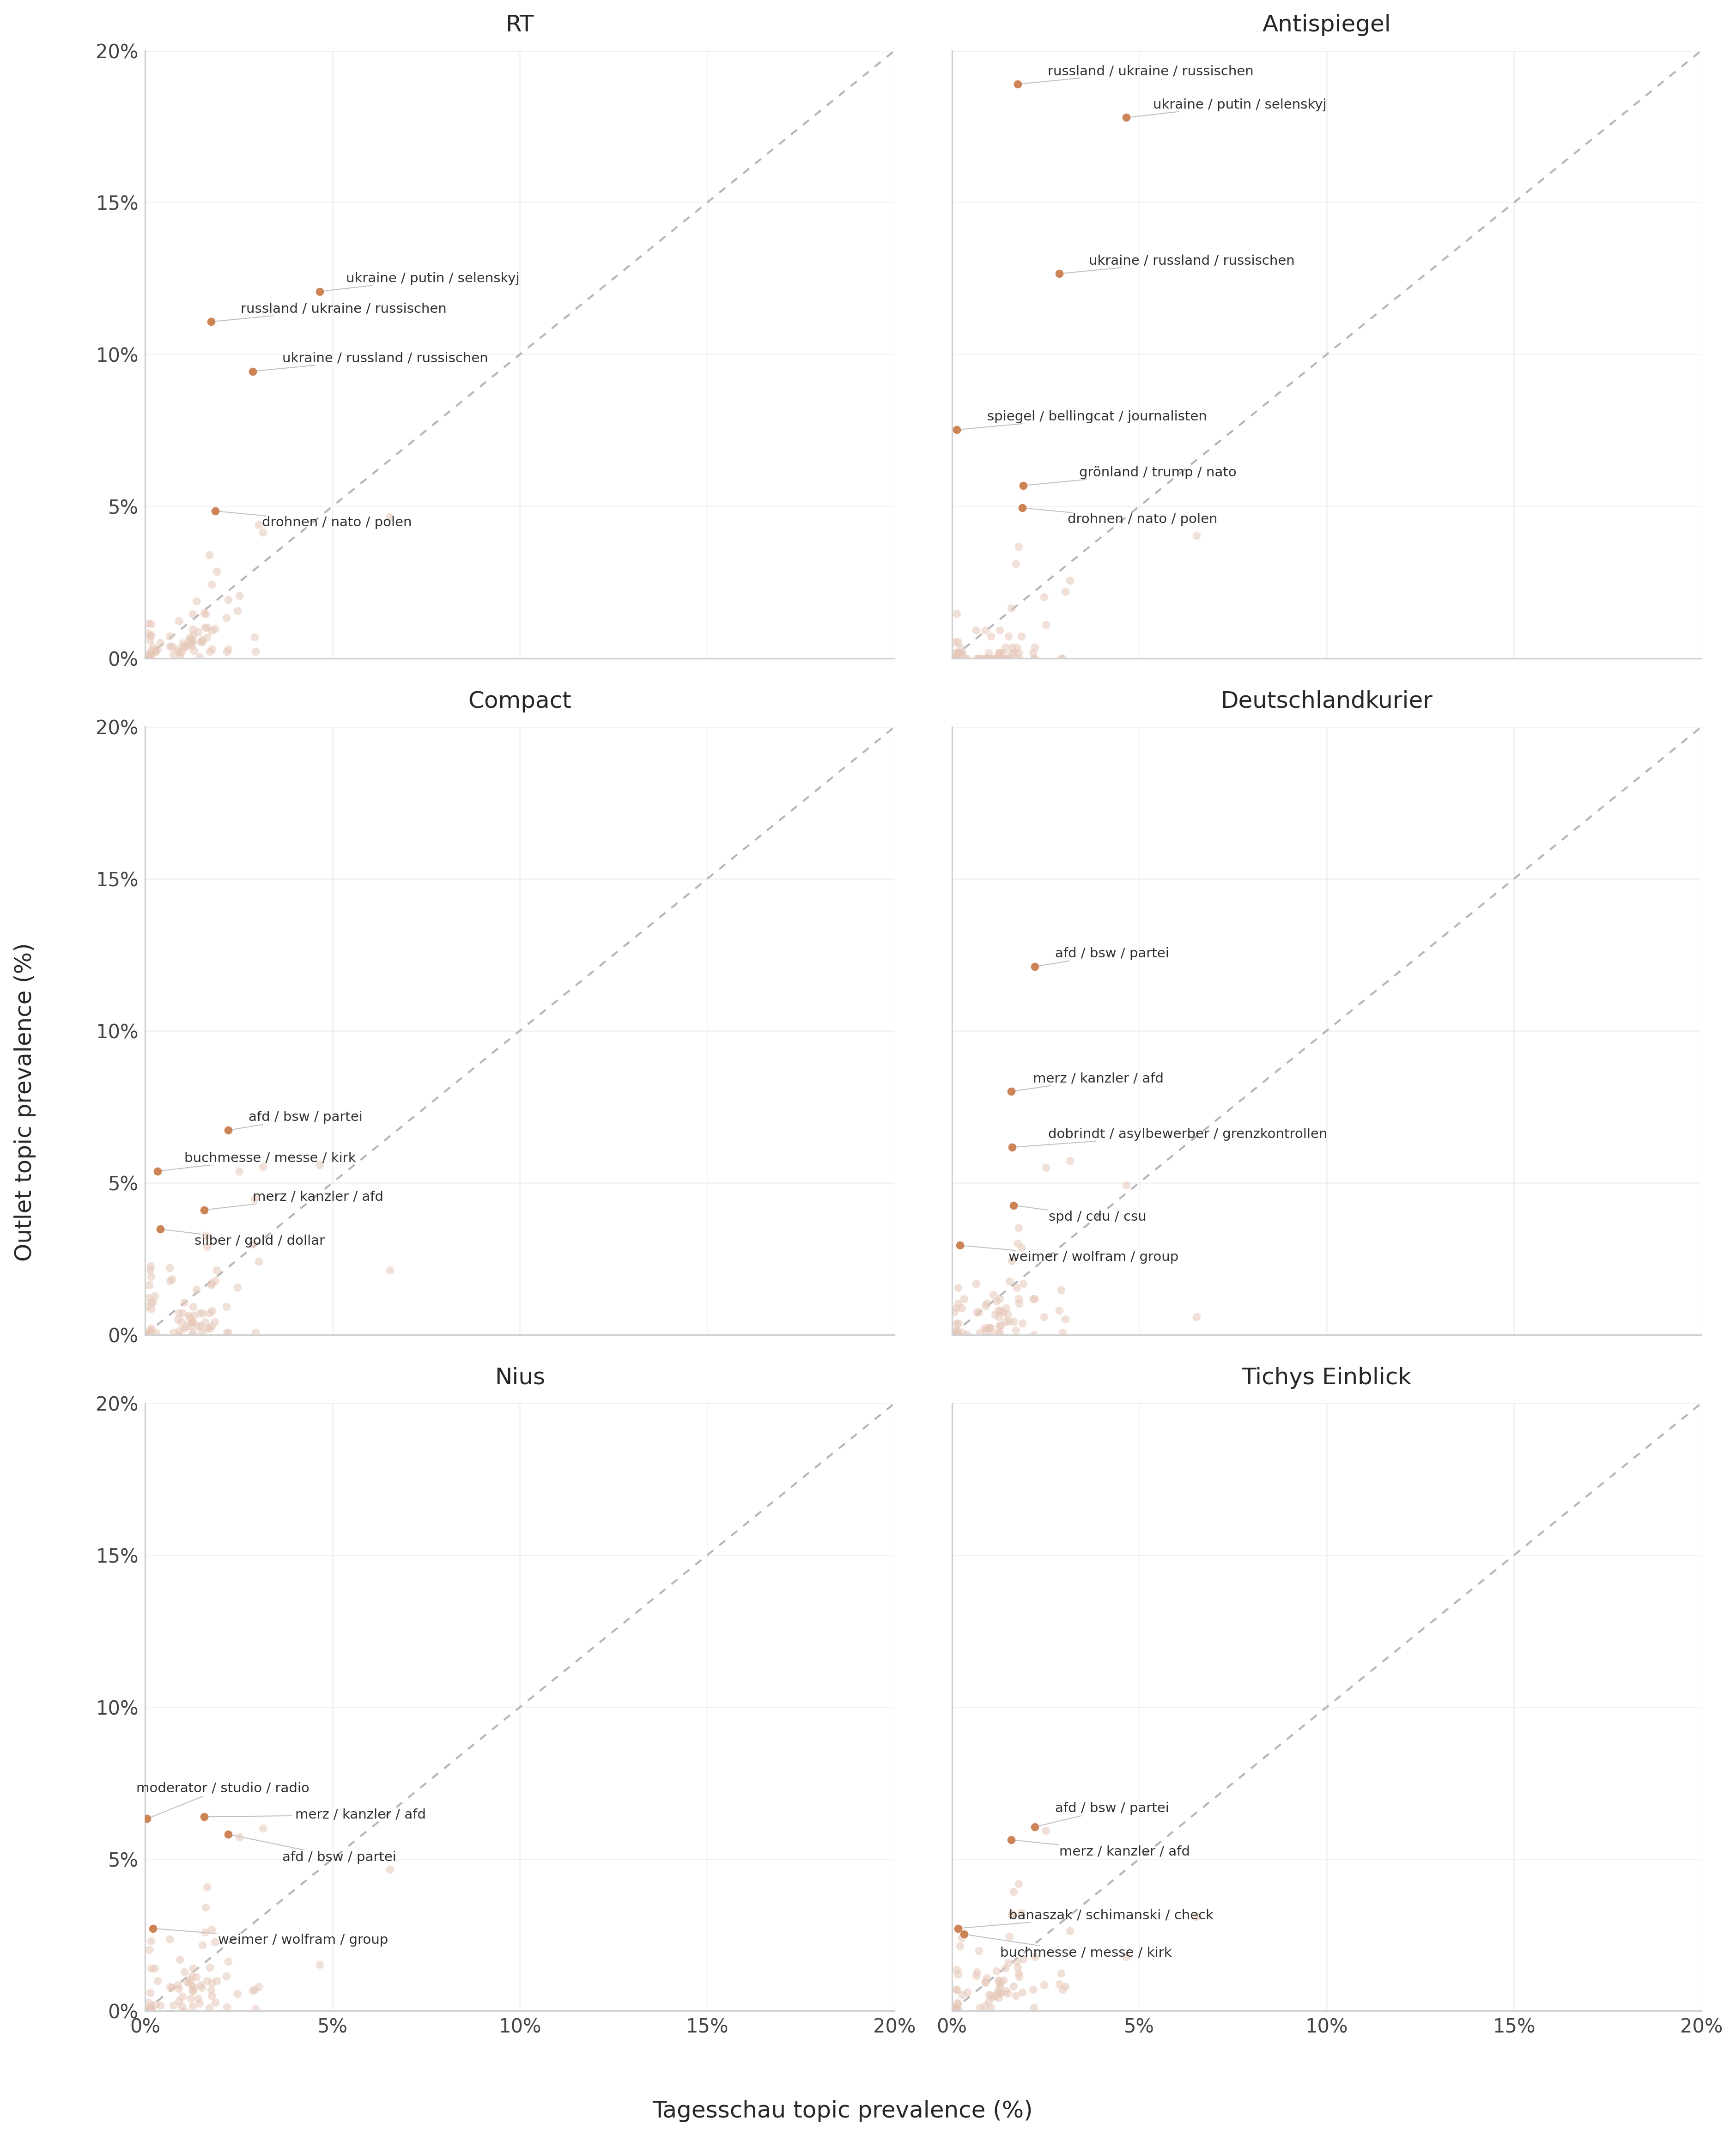

### RT

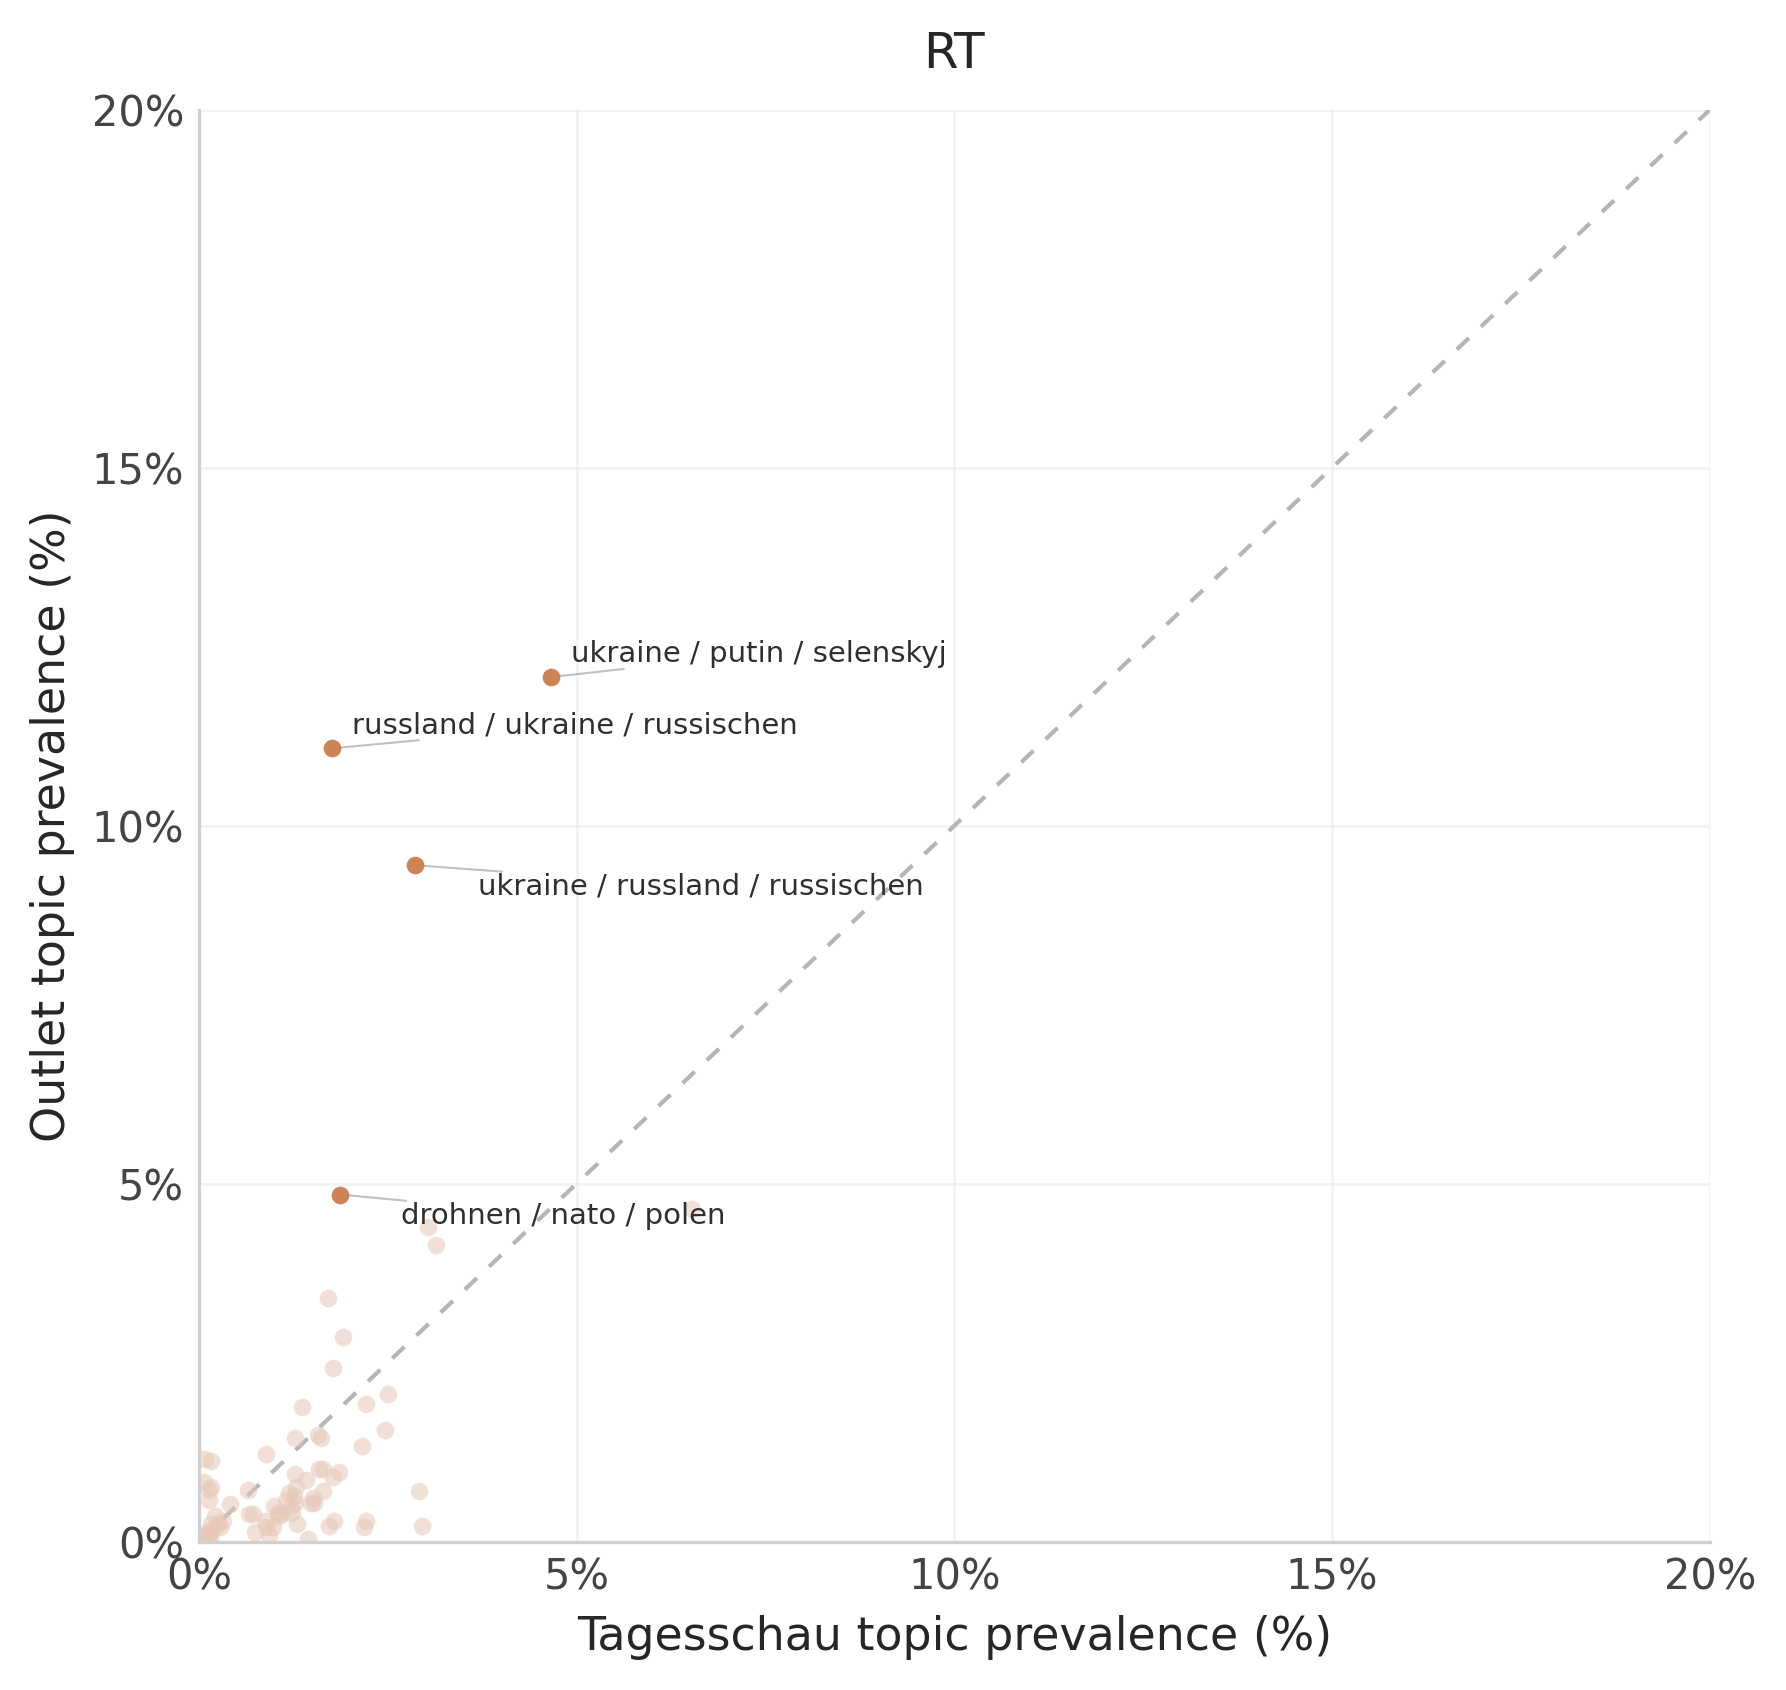

### Antispiegel

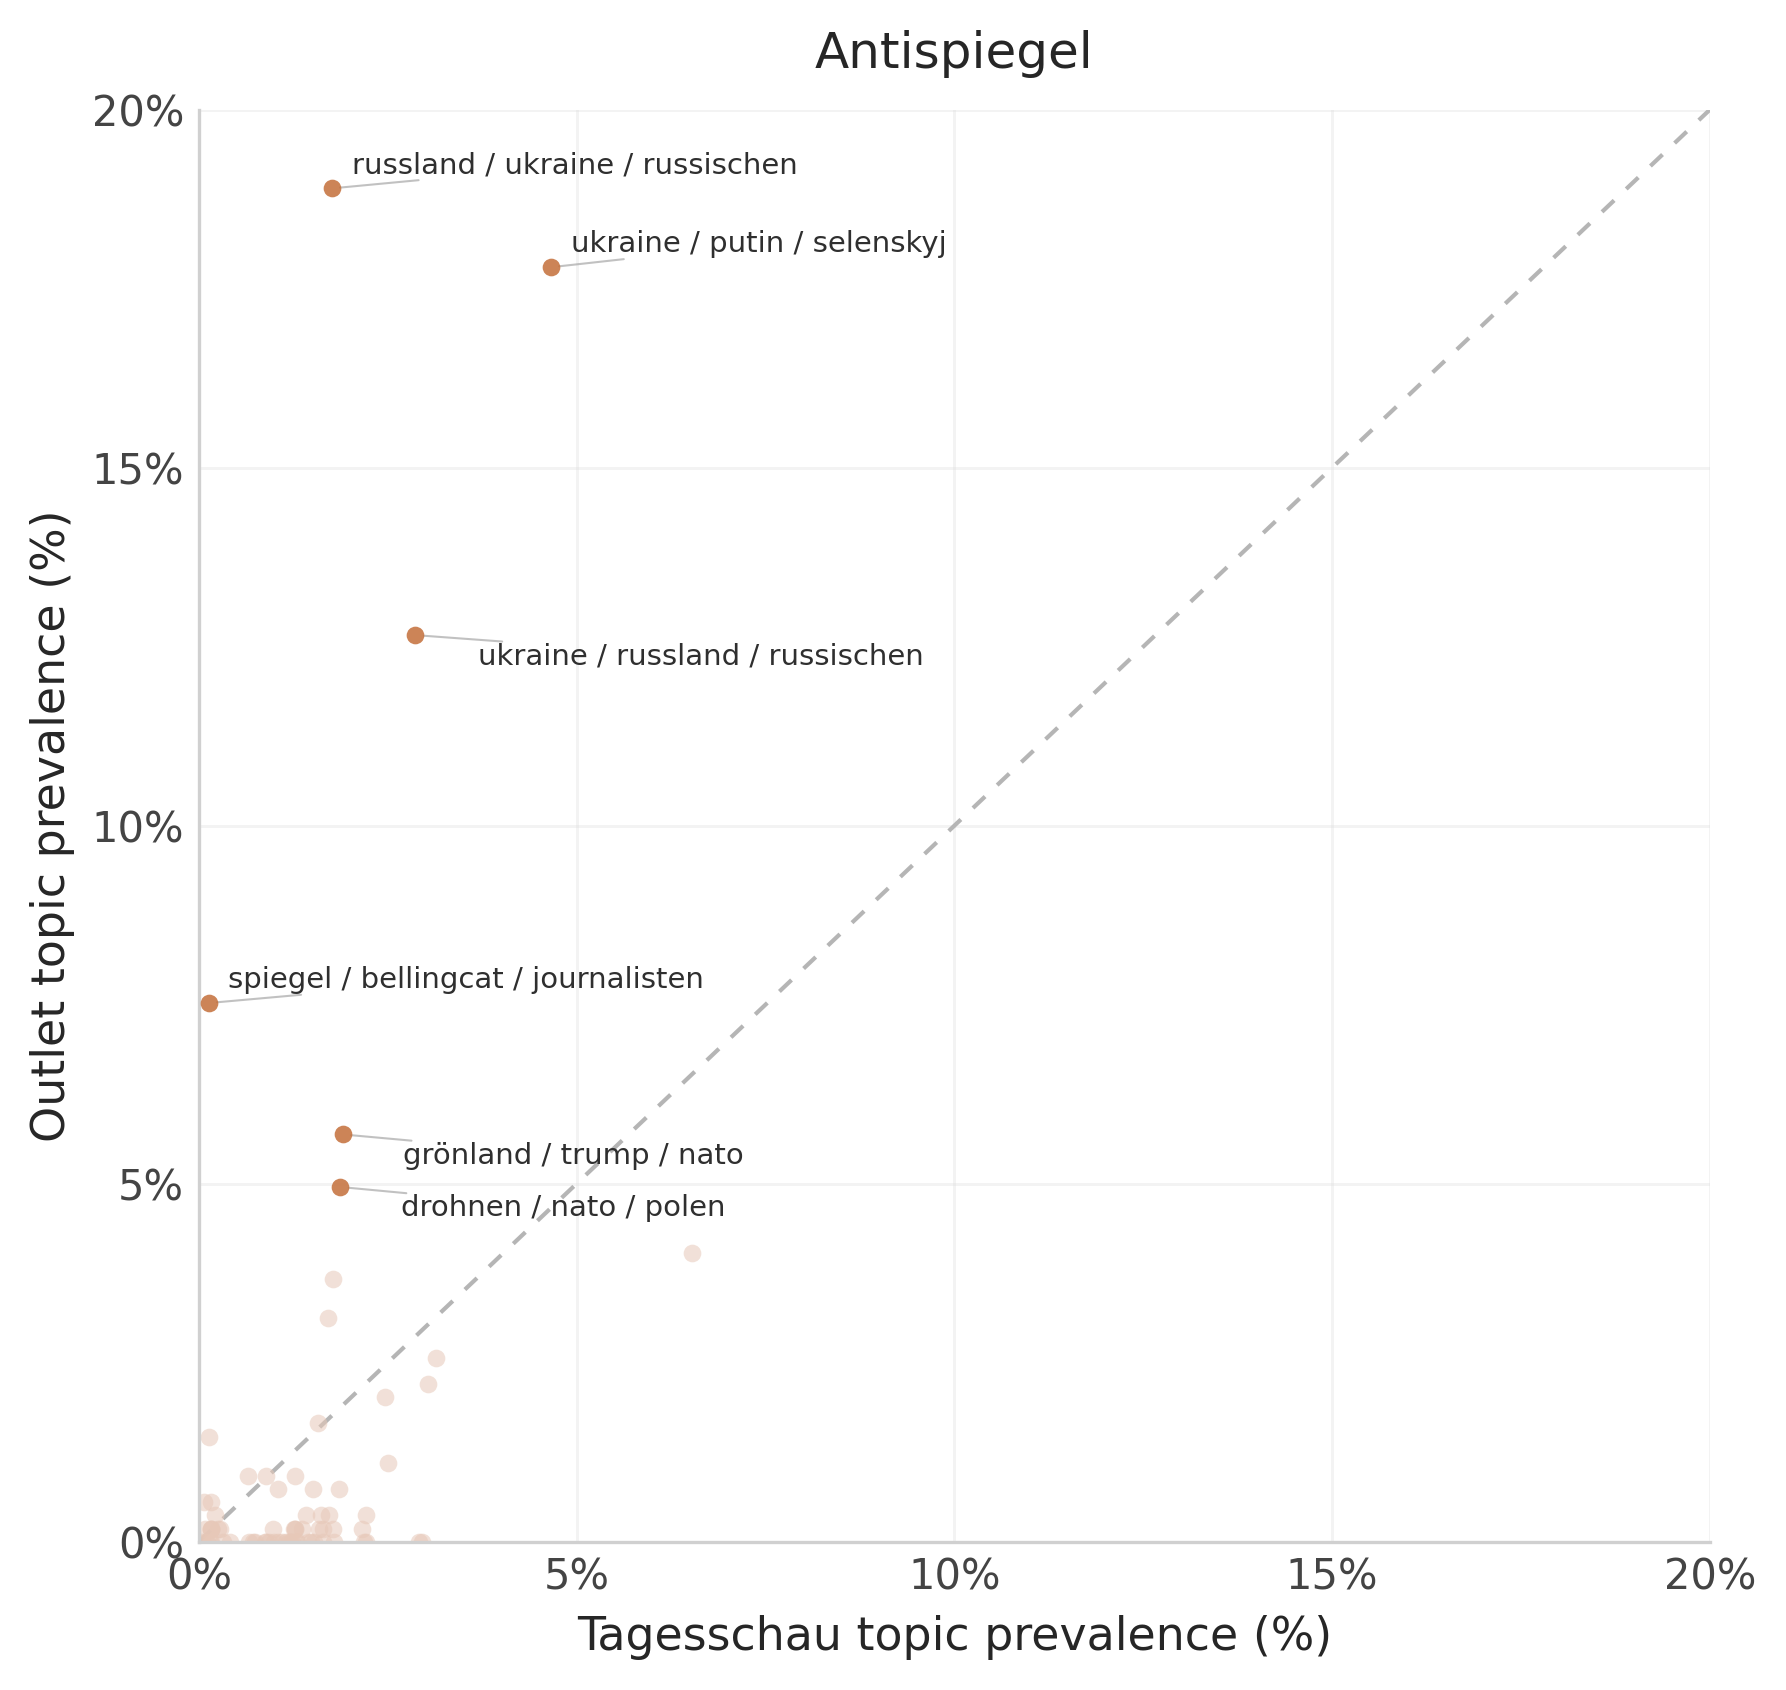

### Compact

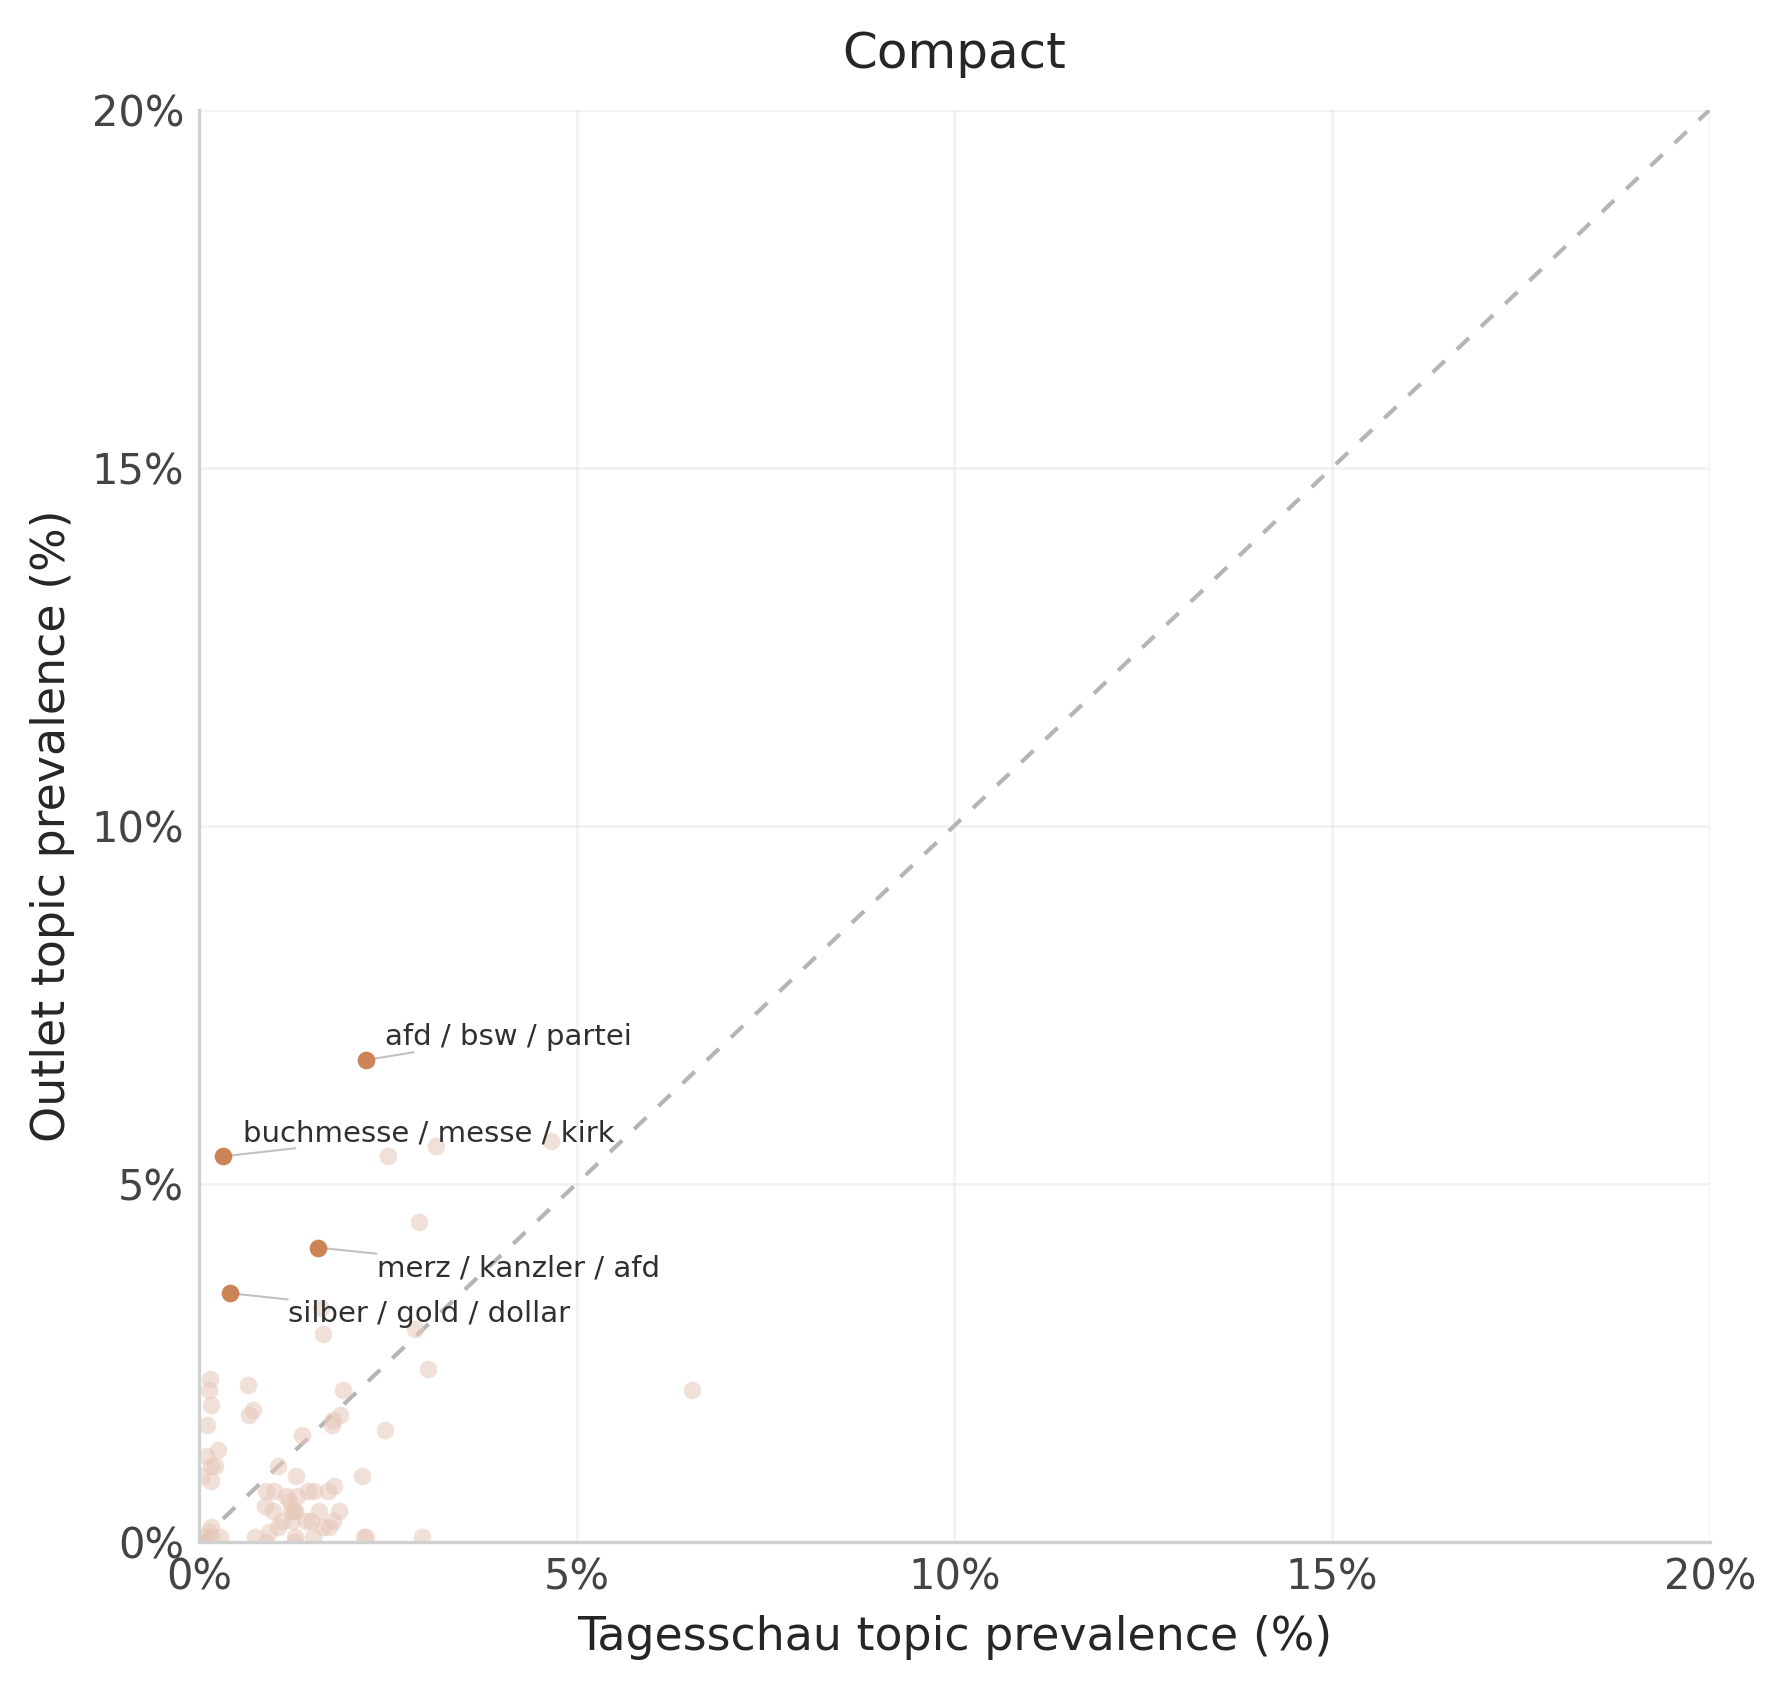

### Deutschlandkurier

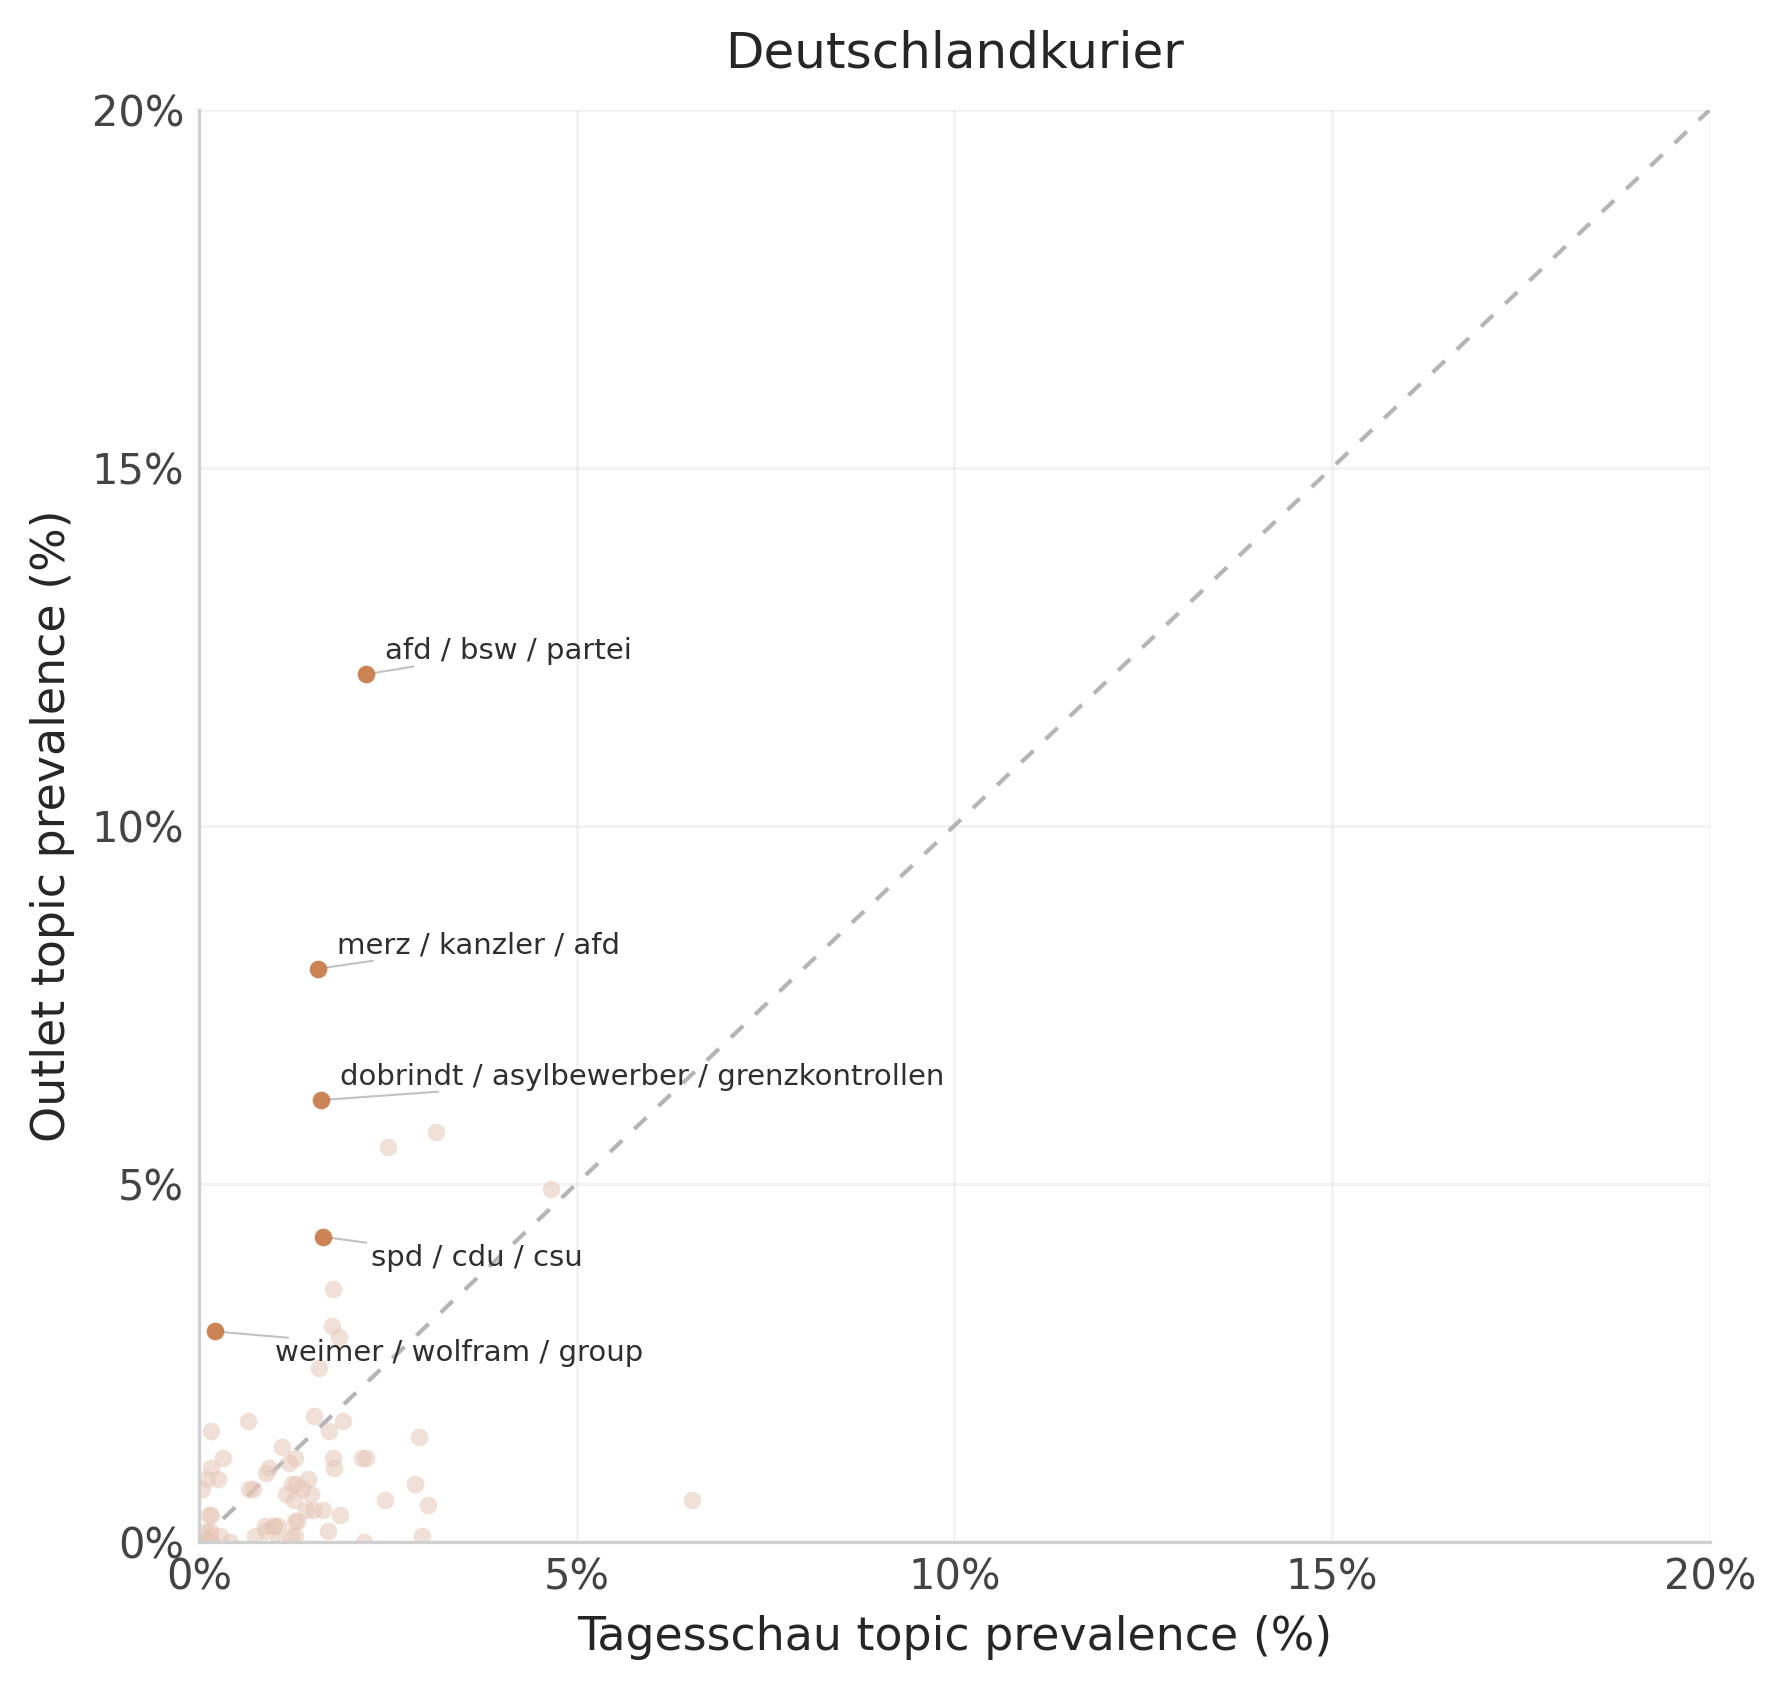

### Nius

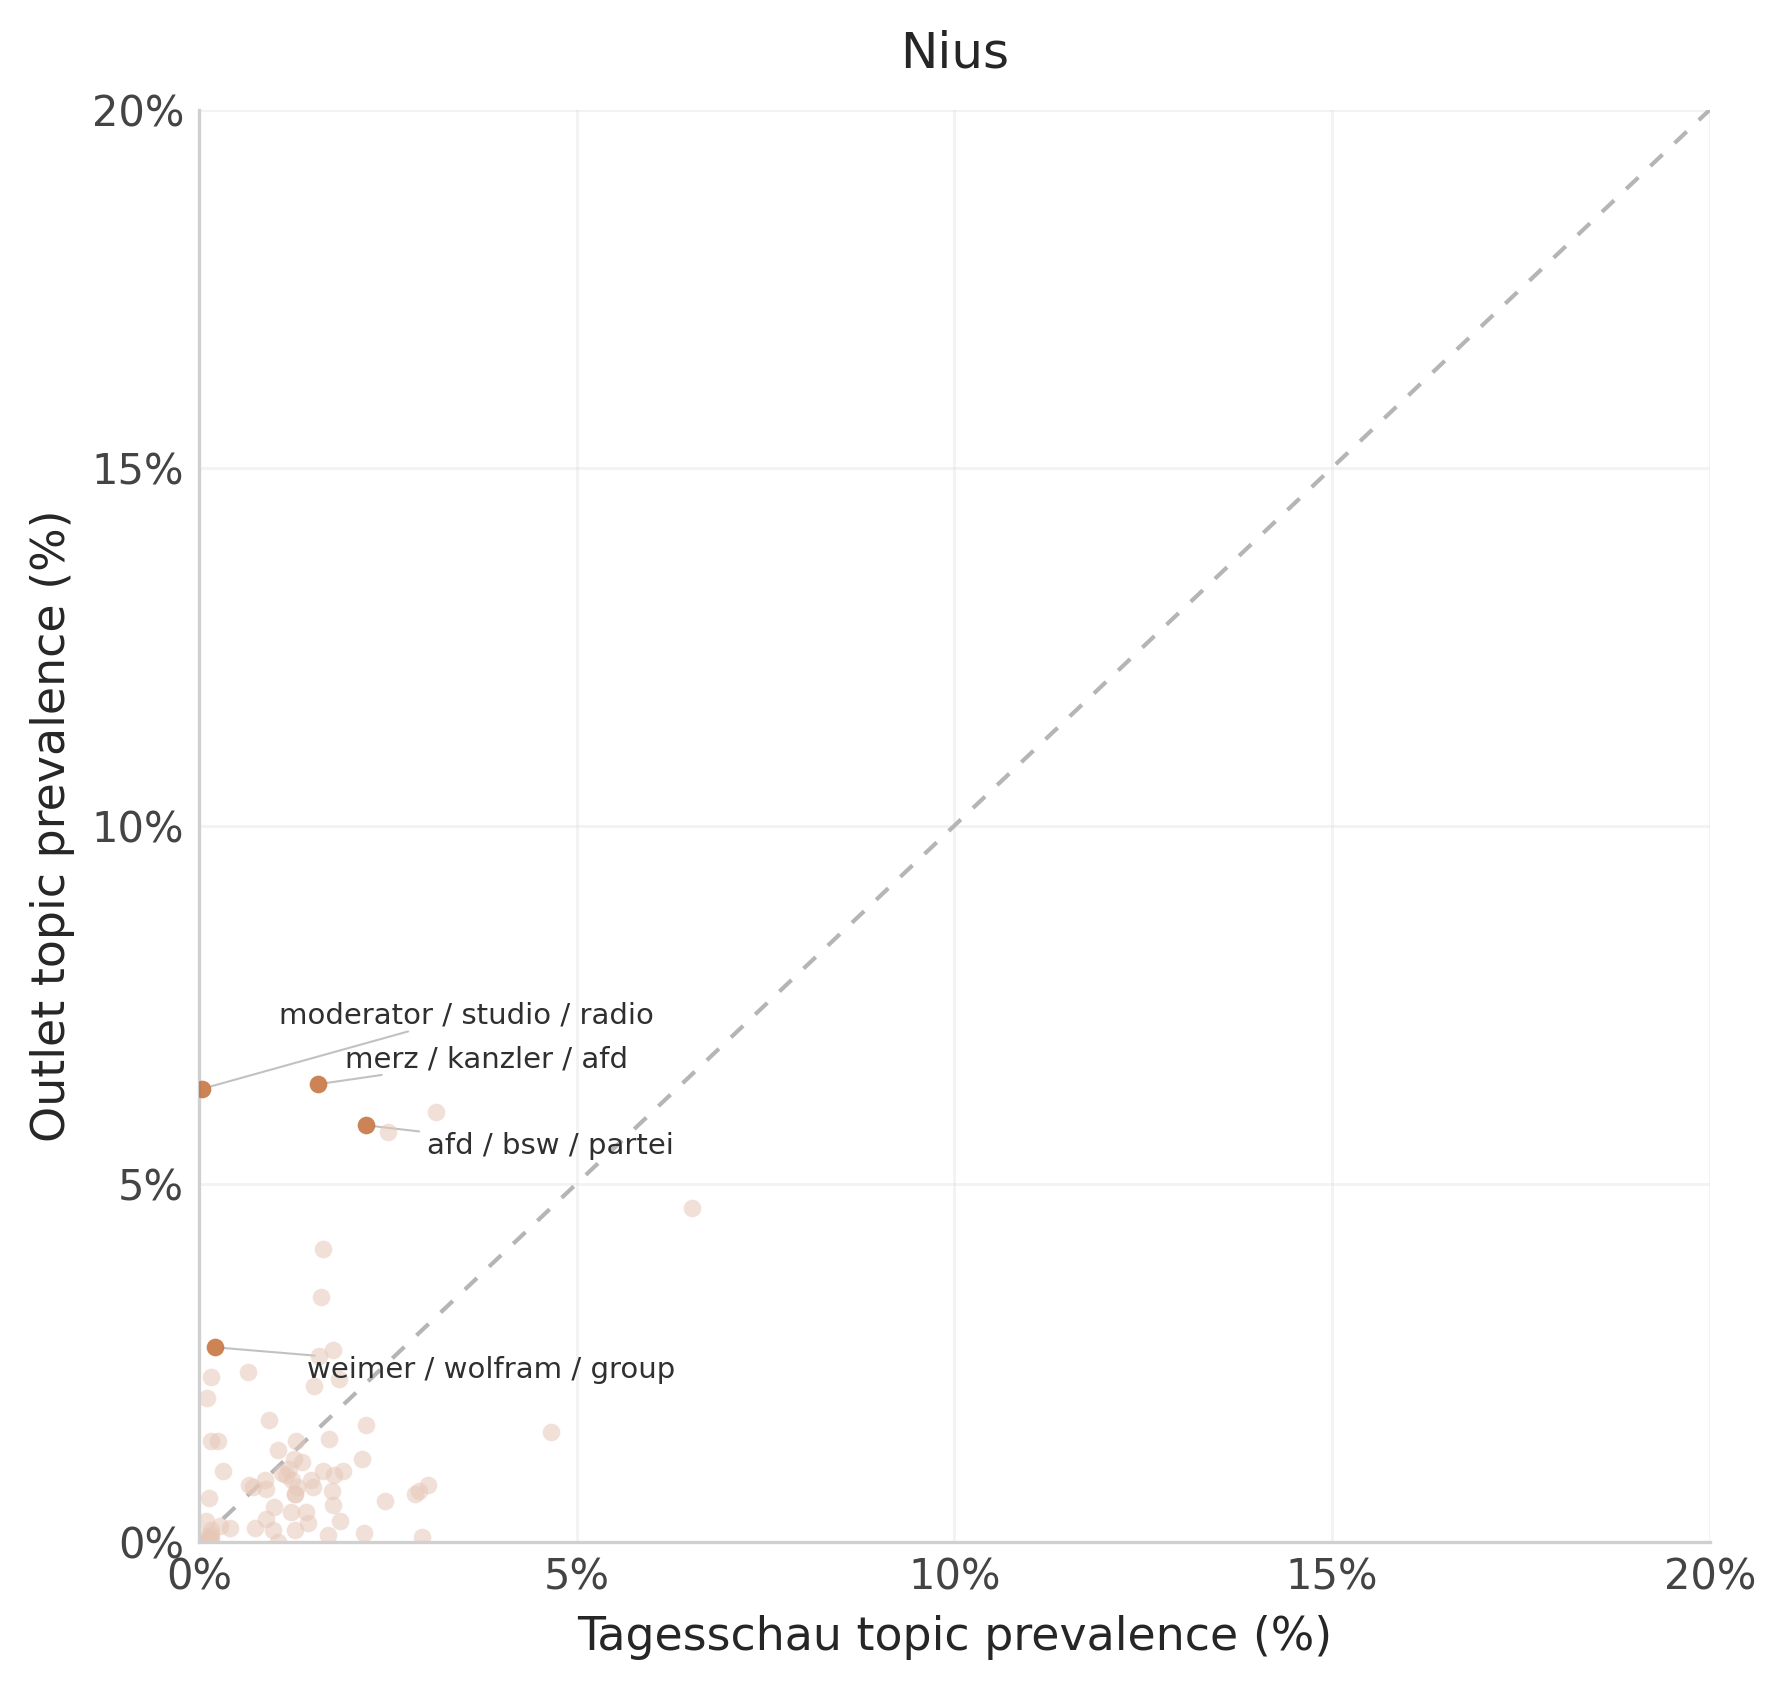

### Tichys Einblick

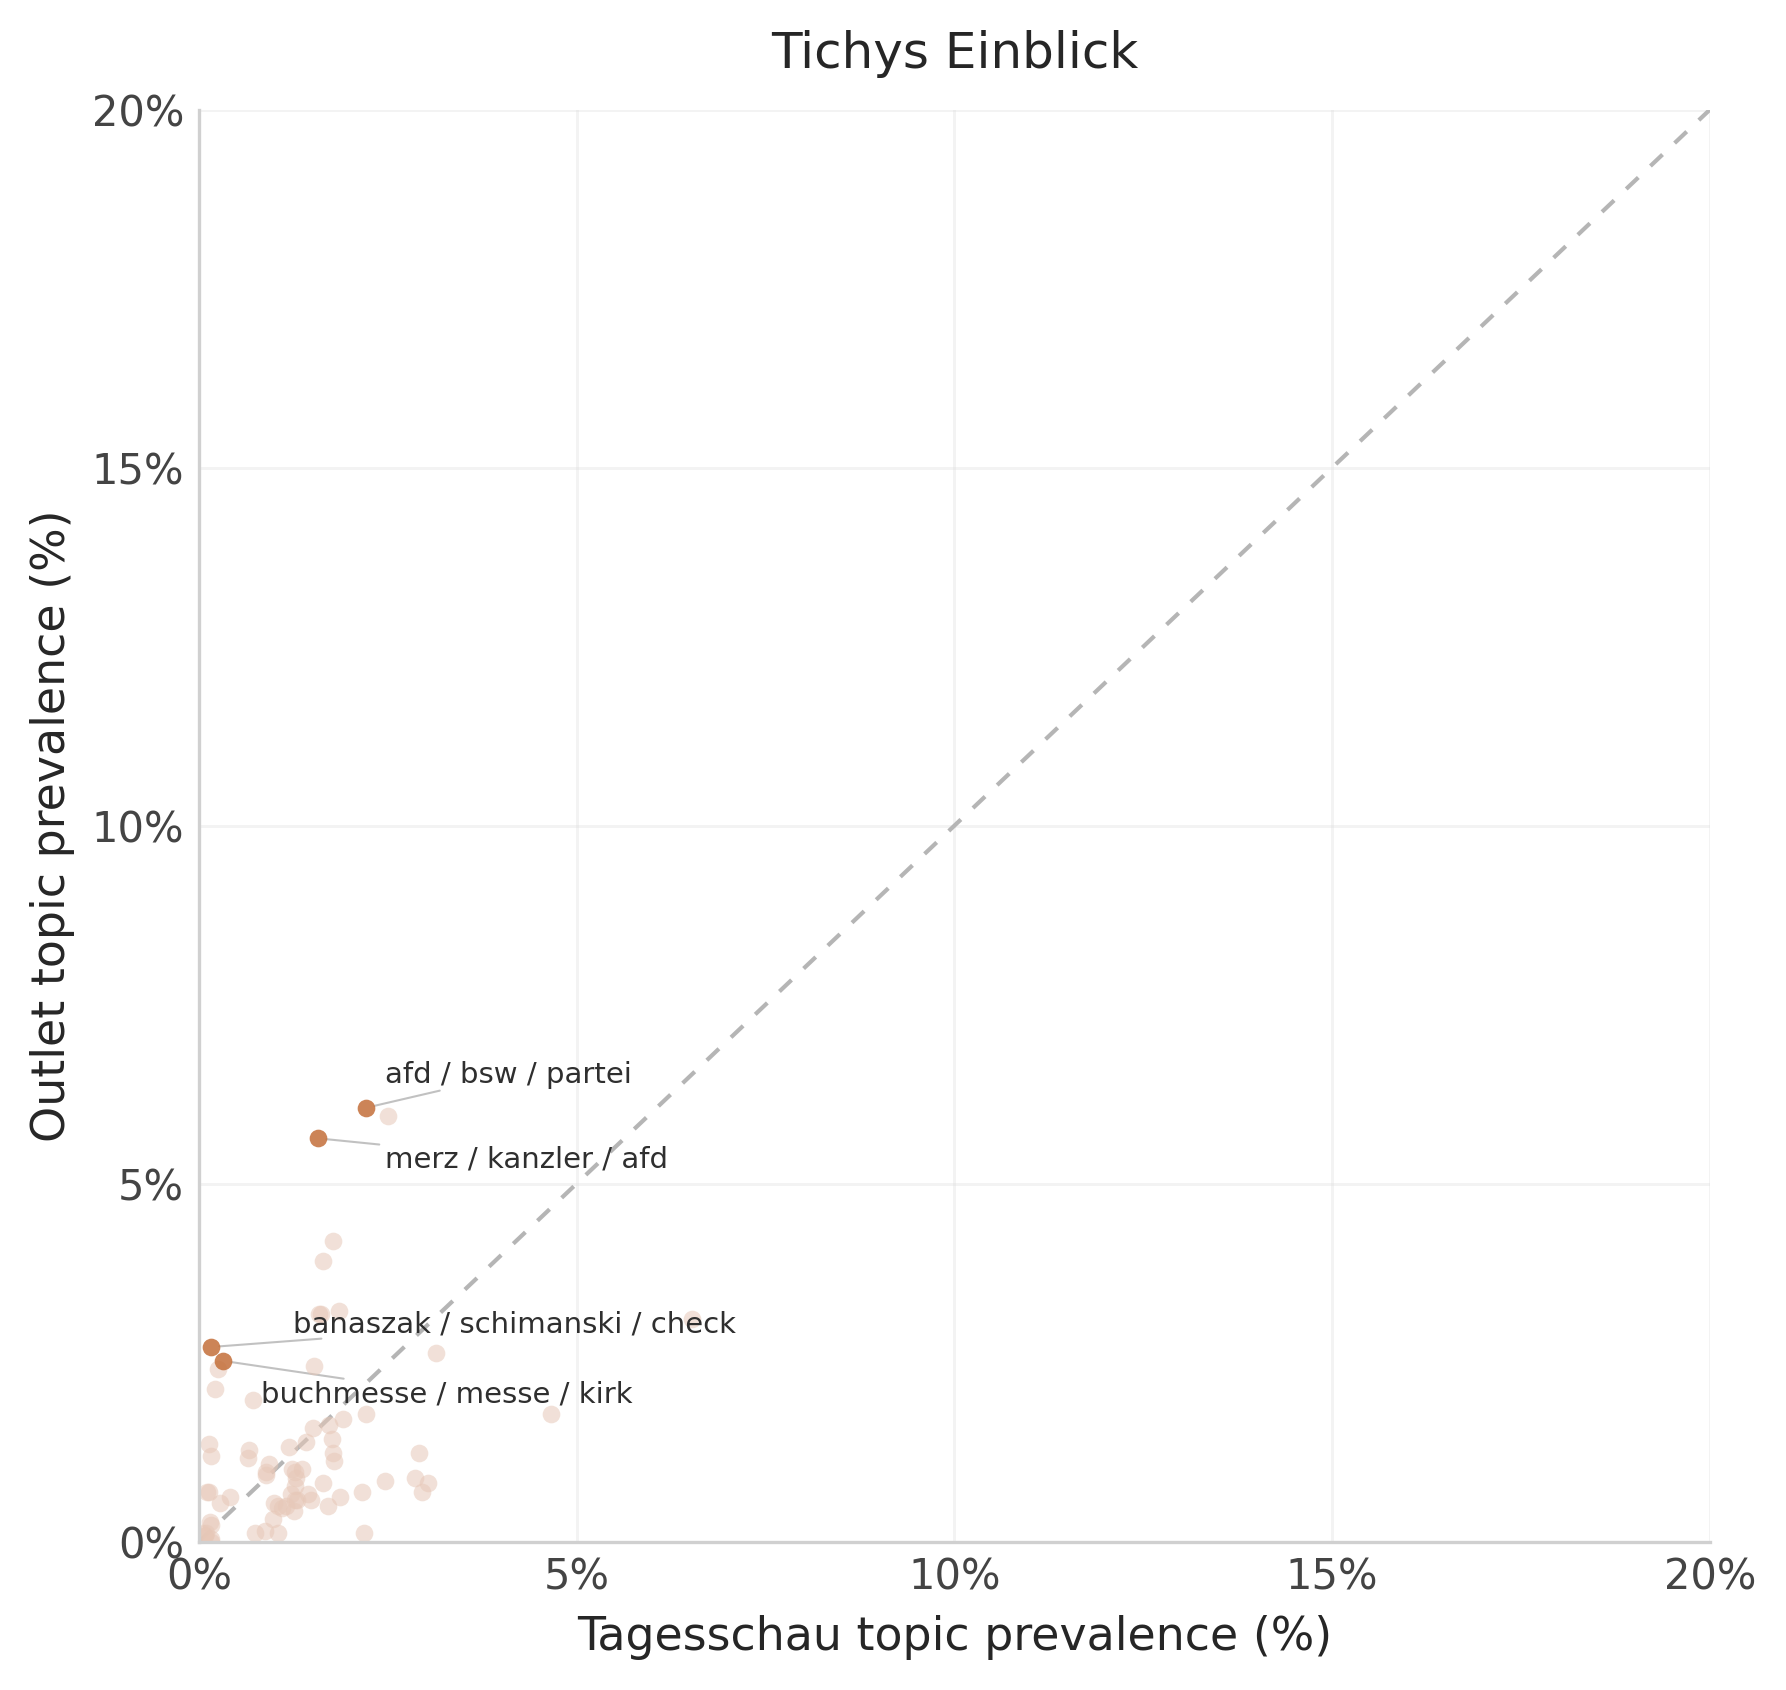

Saved inline preview PNGs:
  - /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/figures/scatter_all_outlets_vs_tagesschau.png
  - /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/figures/scatter_rt_vs_tagesschau.png
  - /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/figures/scatter_antispiegel_vs_tagesschau.png
  - /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/figures/scatter_compact_vs_tagesschau.png
  - /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/figures/scatter_deutschlandkurier_vs_tagesschau.png
  - /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/figures/scatter_nius_vs_tagesschau.png
  - /private/tmp/thesis_merge_main_20260329/experiments/agenda_distortion/outputs/v2/figures/scatter_tichys_vs_tagesschau.png


In [12]:
from IPython.display import Image, Markdown, display

scatter_png_paths = []

with plt.rc_context(PLOT_RC):
    for outlet_key in OUTLET_ORDER:
        fig, ax = plt.subplots(figsize=(6.5, 6.2), dpi=150)
        _plot_single_outlet_scatter(ax, outlet_key)
        ax.set_xlabel("Tagesschau topic prevalence (%)")
        ax.set_ylabel("Outlet topic prevalence (%)")
        png_path = SCATTER_FIGURE_DIR / f"scatter_{outlet_key}_vs_tagesschau.png"
        fig.savefig(png_path, bbox_inches="tight", dpi=300, facecolor="white")
        plt.close(fig)
        scatter_png_paths.append((OUTLET_LABEL_MAP[outlet_key], png_path))

    grid_fig, grid_axes = plt.subplots(
        3,
        2,
        figsize=(13, 16),
        dpi=150,
        sharex=True,
        sharey=True,
    )
    for ax, outlet_key in zip(grid_axes.flat, OUTLET_ORDER):
        _plot_single_outlet_scatter(ax, outlet_key)
    grid_fig.supxlabel("Tagesschau topic prevalence (%)", fontsize=12, y=0.04)
    grid_fig.supylabel("Outlet topic prevalence (%)", fontsize=12, x=0.04)
    grid_fig.tight_layout(rect=(0.05, 0.05, 1.0, 1.0))
    scatter_grid_png_path = SCATTER_FIGURE_DIR / "scatter_all_outlets_vs_tagesschau.png"
    grid_fig.savefig(scatter_grid_png_path, bbox_inches="tight", dpi=300, facecolor="white")
    plt.close(grid_fig)

display(Markdown("### Combined grid"))
display(Image(filename=str(scatter_grid_png_path)))

for outlet_label, png_path in scatter_png_paths:
    display(Markdown(f"### {outlet_label}"))
    display(Image(filename=str(png_path)))

print("Saved inline preview PNGs:")
print(f"  - {scatter_grid_png_path}")
for _, png_path in scatter_png_paths:
    print(f"  - {png_path}")